<a href="https://colab.research.google.com/github/IsaaHack/VC/blob/main/P2_Ejs1y2_TEMPLATE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visión por Computador - Práctica 2 - Deep Learning en Computer Vision

#### 12 puntos   |   Fecha de entrega: 15 de Diciembre, 23:59   |   Forma de entrega: a través de la tarea creada en https://pradogrado2425.ugr.es/

### Estudiante: <mark>ISAAC BRAO AISSAONI</mark>



<font color='blue'>El objetivo de esta práctica es aprender a diseñar, implementar, entrenar y utilizar (es decir, aplicar en inferencia) redes neuronales convolucionales en tareas de visión por computador (clasificación y regresión en imágenes) usando fastai (https://docs.fast.ai/).

<font color='blue'>Se proporciona una guía de ayuda (`Assignment_2_HG.ipynb`) para, entre otras cosas, saber cómo:
1. realizar funciones básicas de lectura de datos, entrenamiento y optimización;
2. crear gráficos para la evolución del error de clasificación en
los conjuntos de entrenamiento y validación;
3. y calcular el error de clasificación en el conjunto de prueba.

In [ ]:
# The first thing we should do is to apply hardware acceleration via GPU. So, we have to go to Editar - Configuracion del Cuaderno - Acelerador por Hardware GPU

# Now we SET UP Fastai
!pip install -Uqq fastbook
!pip install nbdev
import fastbook
fastbook.setup_book()
import fastai
import fastcore
print(f'fastcore version {fastcore.__version__} installed')
print(f'fastai version {fastai.__version__} installed')
from nbdev.showdoc import *
from fastai.vision.all import *

fastcore version 1.7.26 installed
fastai version 2.7.18 installed


In [ ]:
# Function to display evaluation metrics
# Developed by Ignacio Oguiza: https://forums.fast.ai/t/plotting-metrics-after-learning/69937

@patch
@delegates(subplots)
def plot_metrics(self: Recorder, nrows=None, ncols=None, figsize=None, **kwargs):
    metrics = np.stack(self.values)
    names = self.metric_names[1:-1]
    n = len(names) - 1
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = int(np.ceil(n / nrows))
    elif nrows is None: nrows = int(np.ceil(n / ncols))
    elif ncols is None: ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 6, nrows * 4)
    fig, axs = subplots(nrows, ncols, figsize=figsize, **kwargs)
    axs = [ax if i < n else ax.set_axis_off() for i, ax in enumerate(axs.flatten())][:n]
    for i, (name, ax) in enumerate(zip(names, [axs[0]] + axs)):
        ax.plot(metrics[:, i], color='#1f77b4' if i == 0 else '#ff7f0e', label='valid' if i > 0 else 'train')
        ax.set_title(name if i > 1 else 'losses')
        ax.legend(loc='best')
    plt.show()



---



---



---



# <font color='blue'>**Ejercicio 1: BaseNet en CIFAR100 (3 puntos)**

<font color='blue'>**Dataset:**
En este ejercicio, trabajaremos con parte del conjunto de datos CIFAR100 (https://www.cs.toronto.edu/~kriz/cifar.html). Este conjunto de datos consta de $60000$ imágenes en color de $32\times32\times3$ (RGB) que representan 100 clases diferentes ($600$ imágenes por clase). Hay $50000$ imágenes para entrenamiento y $10000$ para test. No obstante, para el desarrollo del ejercicio solo consideraremos $25$ clases (de $100$). Por lo tanto, el conjunto de entrenamiento tendrá $12500$ imágenes y el conjunto de prueba $2500$ imágenes. Los alumnos deben emplear el $10\%$ del conjunto de entrenamiento para  validación.

<font color='blue'>**Modelo BaseNet:**
Comenzamos creando un modelo base llamado *BaseNet* que consta de dos bloques convolucionales (Conv+ReLU) separados por un proceso de *subsampling* (MaxPooling), y una cabeza compuesta por dos capas completamente conectadas (FC) (también llamadas capas densas). La arquitectura precisa se define en la siguiente tabla:

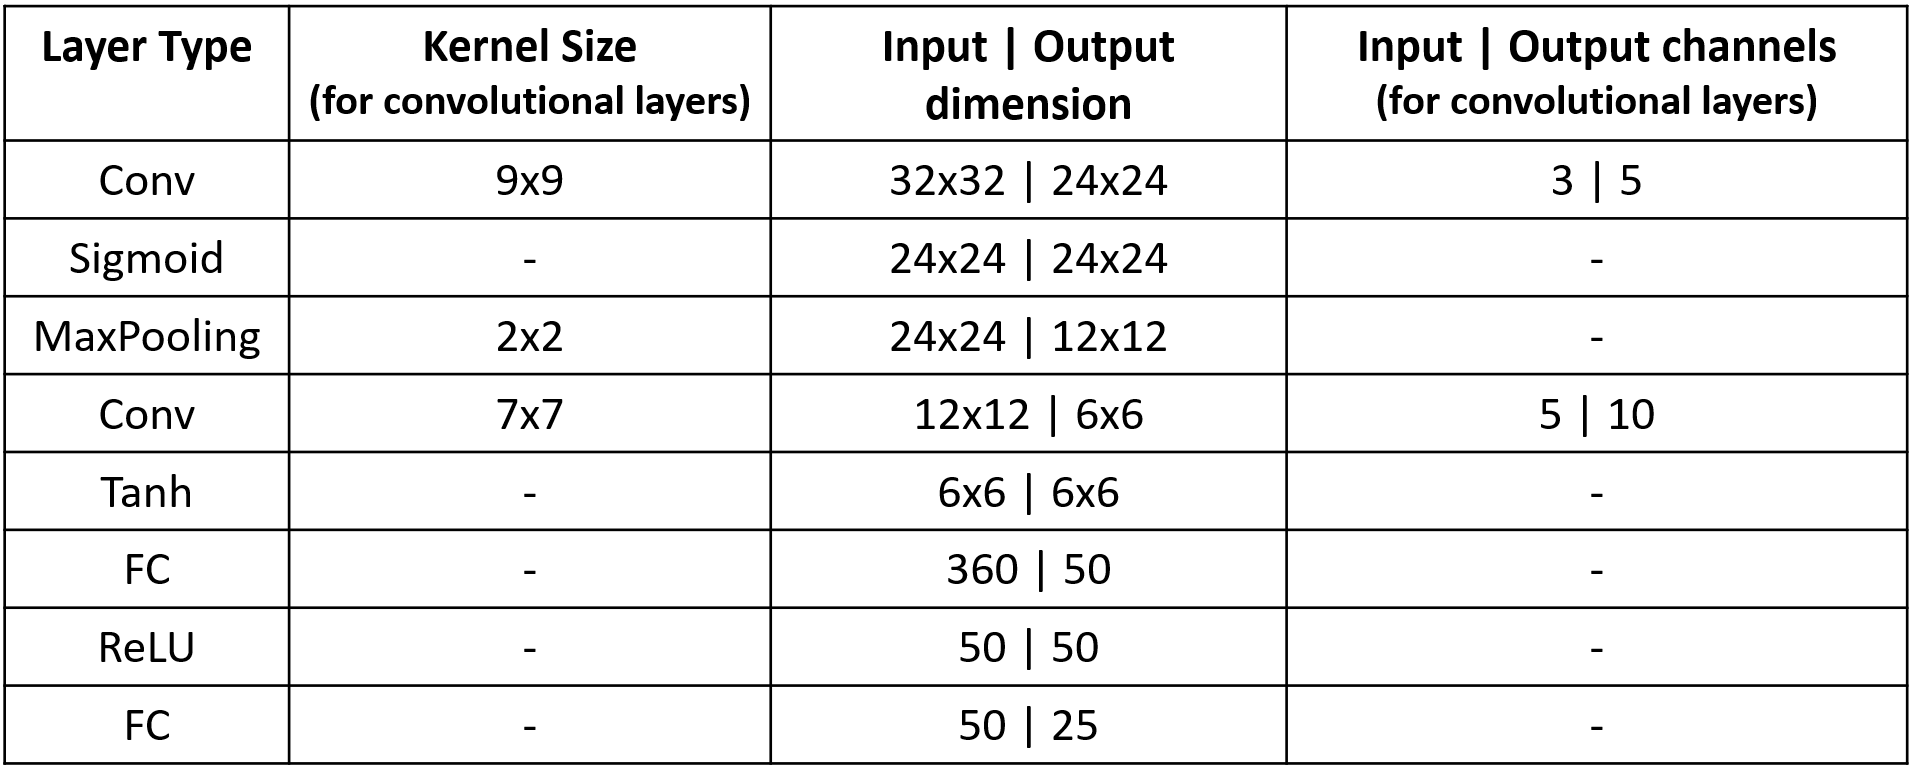

<font color='blue'>Los alumnos deben:
1. Crear el código para el modelo *BaseNet* empleando la librería fastai.
2. Explicar y describir cada una de las capas de la arquitectura *BaseNet*, así como las decisiones de implementación tomadas. Por ejemplo, ¿qué función de pérdida se debería emplear: `CrossEntropyLoss()`, `CrossEntropyLossFlat()` o alguna otra? ¿Se debería incorporar manualmente, en la definición de la red, la función de activación de la capa final (`nn.Softmax()`)? ¿Por qué?
3. Desglosar detalladamente el número de parámetros de esta arquitectura, y cuánto contribuye cada capa a dicho número total. Se debe hacer un `summary()` del modelo para verificar que la arquitectura se ha construido adecuadamente y que el número de parámetros es correcto (es decir, se corresponde con lo esperado).
4. Entrenar el modelo con _Adam_ (incluyendo _early stopping_ con una paciencia de $5$ durante $25$ épocas) y evaluar su rendimiento. En dicha evaluación se debe emplear/mostrar/analizar: la matriz de confusión en entrenamiento, validación y test; la _accuracy_ en entrenamiento, validación y test; y la evolución, por épocas de entrenamiento, tanto de la función de pérdida (en entrenamiento y validación) como de la _accuracy_ (en validación) y el _F1 score (weighted)_ (en validación).



In [ ]:
# We get the CIFAR100 dataset
path = untar_data(URLs.CIFAR_100,force_download=True)
#path = Path('/root/.fastai/data/cifar100')

In [ ]:
# The CIFAR_100 dataset, as well as the MNIST dataset, follows a common layout for machine learning datasets:
# separate folders for the training set and the validation set (and/or test set).
# Let's see what's inside both the training and test sets
print(path)
print(path.ls())
print((path/'train').ls())
print((path/'test').ls())
train_classes = (path/'train').ls()
test_classes = (path/'test').ls()
print(len(train_classes))

/root/.fastai/data/cifar100
[Path('/root/.fastai/data/cifar100/train'), Path('/root/.fastai/data/cifar100/test')]
[Path('/root/.fastai/data/cifar100/train/insects'), Path('/root/.fastai/data/cifar100/train/reptiles'), Path('/root/.fastai/data/cifar100/train/people'), Path('/root/.fastai/data/cifar100/train/aquatic_mammals'), Path('/root/.fastai/data/cifar100/train/medium_mammals'), Path('/root/.fastai/data/cifar100/train/large_man-made_outdoor_things'), Path('/root/.fastai/data/cifar100/train/fruit_and_vegetables'), Path('/root/.fastai/data/cifar100/train/food_containers'), Path('/root/.fastai/data/cifar100/train/small_mammals'), Path('/root/.fastai/data/cifar100/train/household_electrical_devices'), Path('/root/.fastai/data/cifar100/train/large_natural_outdoor_scenes'), Path('/root/.fastai/data/cifar100/train/household_furniture'), Path('/root/.fastai/data/cifar100/train/non-insect_invertebrates'), Path('/root/.fastai/data/cifar100/train/fish'), Path('/root/.fastai/data/cifar100/train

Vemos que hay 20 clases, pero eso no debe confundirnos. Eso son solo las 20 superclases en que está subdividido el dataset. Véase https://github.com/fastai/dlcert2/blob/master/docs/datasets.md:
"This dataset is just like the CIFAR-10, except it has 100 classes containing 600 images each. There are 500 training images and 100 testing images per class. **The 100 classes in the CIFAR-100 are grouped into 20 superclasses**. Each image comes with a "fine" label (the class to which it belongs) and a "coarse" label (the superclass to which it belongs)."

In [ ]:
# Queremos verificar que dentro de cada una de las 20 superclases hay 5 clases,
# lo que da las 100 clases que hay. También queremos verificar que el número de imágenes
# es correcto
print('Clases dentro de la primera superclase (',train_classes[0],'): ', train_classes[0].ls())
for i in range(20):
  print('Número de clases dentro de superclase ',i,': ', len(train_classes[i].ls()))
files_train = get_image_files(path/'train')
files_test = get_image_files(path/'test')
print('Total training images: ', len(files_train))
print('Total test images: ', len(files_test))

Clases dentro de la primera superclase ( /root/.fastai/data/cifar100/train/insects ):  [Path('/root/.fastai/data/cifar100/train/insects/cockroach'), Path('/root/.fastai/data/cifar100/train/insects/beetle'), Path('/root/.fastai/data/cifar100/train/insects/bee'), Path('/root/.fastai/data/cifar100/train/insects/butterfly'), Path('/root/.fastai/data/cifar100/train/insects/caterpillar')]
Número de clases dentro de superclase  0 :  5
Número de clases dentro de superclase  1 :  5
Número de clases dentro de superclase  2 :  5
Número de clases dentro de superclase  3 :  5
Número de clases dentro de superclase  4 :  5
Número de clases dentro de superclase  5 :  5
Número de clases dentro de superclase  6 :  5
Número de clases dentro de superclase  7 :  5
Número de clases dentro de superclase  8 :  5
Número de clases dentro de superclase  9 :  5
Número de clases dentro de superclase  10 :  5
Número de clases dentro de superclase  11 :  5
Número de clases dentro de superclase  12 :  5
Número de cla

Ahora nos quedamos con las primeras 25 clases. Lo que hacemos es eliminar las 75 últimas del dataset.

In [ ]:
#https://stackoverflow.com/questions/185936/how-to-delete-the-contents-of-a-folder
import shutil
number_of_classes_to_keep = 25
number_of_superclasses_to_keep = int(number_of_classes_to_keep/5)
print('SUPERCLASES ELIMINADAS:')
for i in range(number_of_superclasses_to_keep,len(train_classes)):
  print(train_classes[i])
  shutil.rmtree(train_classes[i])
print('SUPERCLASES CONSERVADAS:')
for i in range(number_of_superclasses_to_keep):
  print(train_classes[i])

SUPERCLASES ELIMINADAS:
/root/.fastai/data/cifar100/train/large_man-made_outdoor_things
/root/.fastai/data/cifar100/train/fruit_and_vegetables
/root/.fastai/data/cifar100/train/food_containers
/root/.fastai/data/cifar100/train/small_mammals
/root/.fastai/data/cifar100/train/household_electrical_devices
/root/.fastai/data/cifar100/train/large_natural_outdoor_scenes
/root/.fastai/data/cifar100/train/household_furniture
/root/.fastai/data/cifar100/train/non-insect_invertebrates
/root/.fastai/data/cifar100/train/fish
/root/.fastai/data/cifar100/train/vehicles_2
/root/.fastai/data/cifar100/train/vehicles_1
/root/.fastai/data/cifar100/train/flowers
/root/.fastai/data/cifar100/train/large_carnivores
/root/.fastai/data/cifar100/train/large_omnivores_and_herbivores
/root/.fastai/data/cifar100/train/trees
SUPERCLASES CONSERVADAS:
/root/.fastai/data/cifar100/train/insects
/root/.fastai/data/cifar100/train/reptiles
/root/.fastai/data/cifar100/train/people
/root/.fastai/data/cifar100/train/aquatic_

In [ ]:
# También eliminamos las clases en test
for i in range(number_of_superclasses_to_keep,len(test_classes)):
  print(test_classes[i])
  shutil.rmtree(test_classes[i])

/root/.fastai/data/cifar100/test/large_man-made_outdoor_things
/root/.fastai/data/cifar100/test/fruit_and_vegetables
/root/.fastai/data/cifar100/test/food_containers
/root/.fastai/data/cifar100/test/small_mammals
/root/.fastai/data/cifar100/test/household_electrical_devices
/root/.fastai/data/cifar100/test/large_natural_outdoor_scenes
/root/.fastai/data/cifar100/test/household_furniture
/root/.fastai/data/cifar100/test/non-insect_invertebrates
/root/.fastai/data/cifar100/test/fish
/root/.fastai/data/cifar100/test/vehicles_2
/root/.fastai/data/cifar100/test/vehicles_1
/root/.fastai/data/cifar100/test/flowers
/root/.fastai/data/cifar100/test/large_carnivores
/root/.fastai/data/cifar100/test/large_omnivores_and_herbivores
/root/.fastai/data/cifar100/test/trees


Ahora intentamos verificar si los hemos eliminado realmente.

In [ ]:
print(path)
train_classes = (path/'train').ls()
test_classes = (path/'test').ls()
print(len(train_classes))
print(len(test_classes))

/root/.fastai/data/cifar100
5
5


Y que el número de ejemplos en training y test es el correcto.

In [ ]:
print('Clases dentro de la primera superclase (',train_classes[0],'): ', train_classes[0].ls())
files_train = get_image_files(path/'train')
files_test = get_image_files(path/'test')
print('Total training images: ', len(files_train))
print('Total test images: ', len(files_test))

Clases dentro de la primera superclase ( /root/.fastai/data/cifar100/train/insects ):  [Path('/root/.fastai/data/cifar100/train/insects/cockroach'), Path('/root/.fastai/data/cifar100/train/insects/beetle'), Path('/root/.fastai/data/cifar100/train/insects/bee'), Path('/root/.fastai/data/cifar100/train/insects/butterfly'), Path('/root/.fastai/data/cifar100/train/insects/caterpillar')]
Total training images:  12500
Total test images:  2500


Podemos observar que ahora tenemos el dataset tal y como nos interesa, con 12500 imágenes de entrenamiento y 2500 de test.

Ahora vamos a proceder a cargar los datos de entrenamiento. Para ello hacemos uso de DataLoaders y DataBlock.

Aquí defino el datablock y el dataloader.

Se dice que es un bloque de datos de imágenes, y que se va a clasificar con ImageBlock y CategoryBlock, respectivamente. Además se pasa una función para obtener las imagenes y las etiquetas. Después se dividen los datos en entrenamiento y validación, con un 10% de los datos para validación, según el parámetro valid_pct.

En el datablock se definen las transformaciones que se van a aplicar a las imágenes. En este caso, se van a normalizar con los valores de la media y la desviación estándar de ImageNet, para utilizar valores que ya han sido precalculados y que son los que se utilizan en la mayoría de los modelos preentrenados. Además, se van a hacer aumentos de datos, con los valores predeterminados de la librería fastai. Estos son:

- Flip: con una probabilidad del 0.5, se hace un flip horizontal de la imagen.
- Warp: se hace una deformación aleatoria de la imagen.
- Zoom: se hace un zoom aleatorio de la imagen.
- Brightness: se cambia el brillo de la imagen de forma aleatoria.
- Contrast: se cambia el contraste de la imagen de forma aleatoria.
- Rotate: se rota la imagen de forma aleatoria.

En el DataLoader se definen los tamaños de los lotes que se va a utilizar para entrenar y validar el modelo. En este caso, se ha definido un tamaño de lote de 128 para un buen rendimiento en la GPU. Si aumentamos el tamaño del lote, se puede mejorar el rendimiento, pero también se puede aumentar el uso de memoria de la GPU. Además, si usas un tamaño de lote muy grande, puedes tener problemas de sobreajuste.

Numero de ejemplos de entrenamiento (una vez descartados los de validacion): 11250
Numero de ejemplos de validacion: 1250


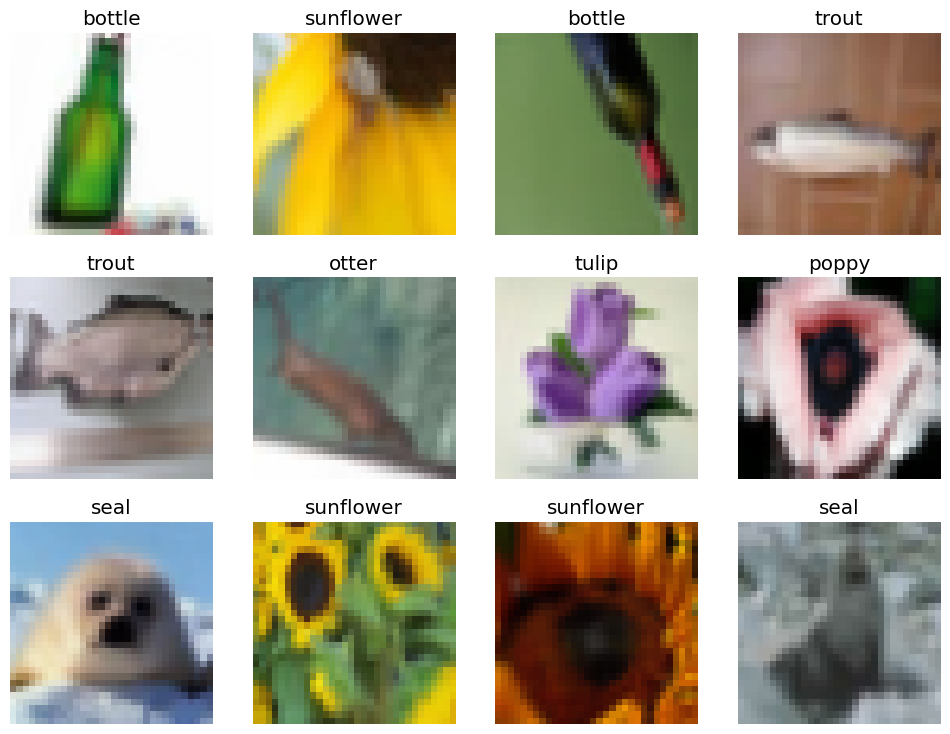

In [ ]:
# A CUBRIR POR EL ALUMNADO
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.1, seed=42),
    get_y=parent_label,
    batch_tfms=[*aug_transforms(), Normalize.from_stats(*imagenet_stats)]
).dataloaders(path/'train', bs=128, to_device='cuda')

dls.show_batch(max_n=12)

print('Numero de ejemplos de entrenamiento (una vez descartados los de validacion):', len(dls.train_ds))
print('Numero de ejemplos de validacion:', len(dls.valid_ds))

Example of training data


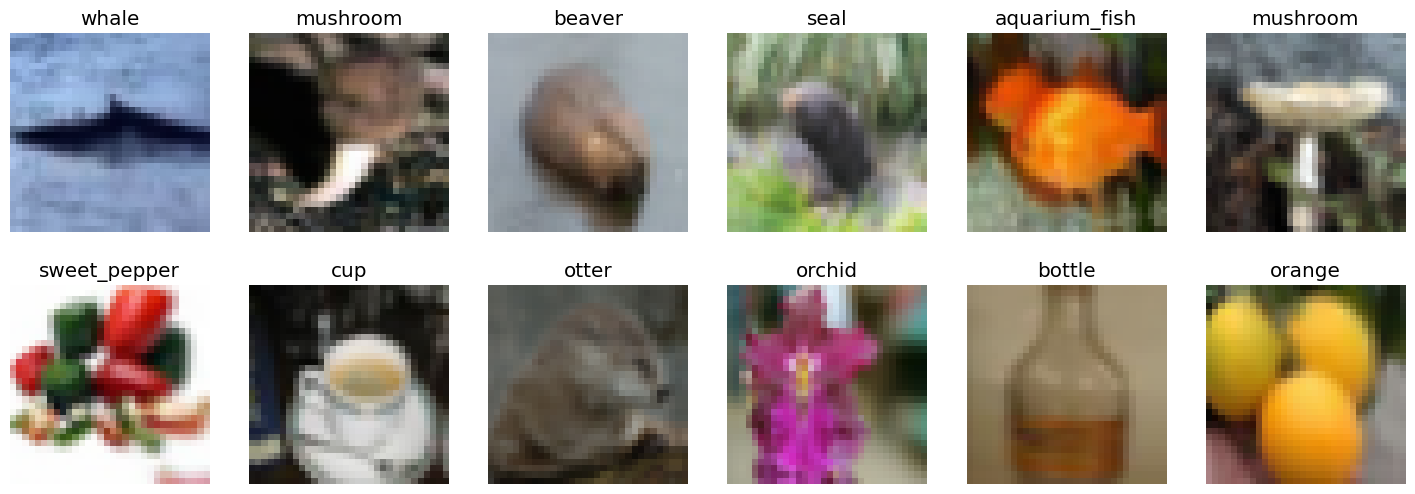

In [ ]:
print('Example of training data')
dls.train.show_batch(max_n=12, nrows=2)

Example of validation data


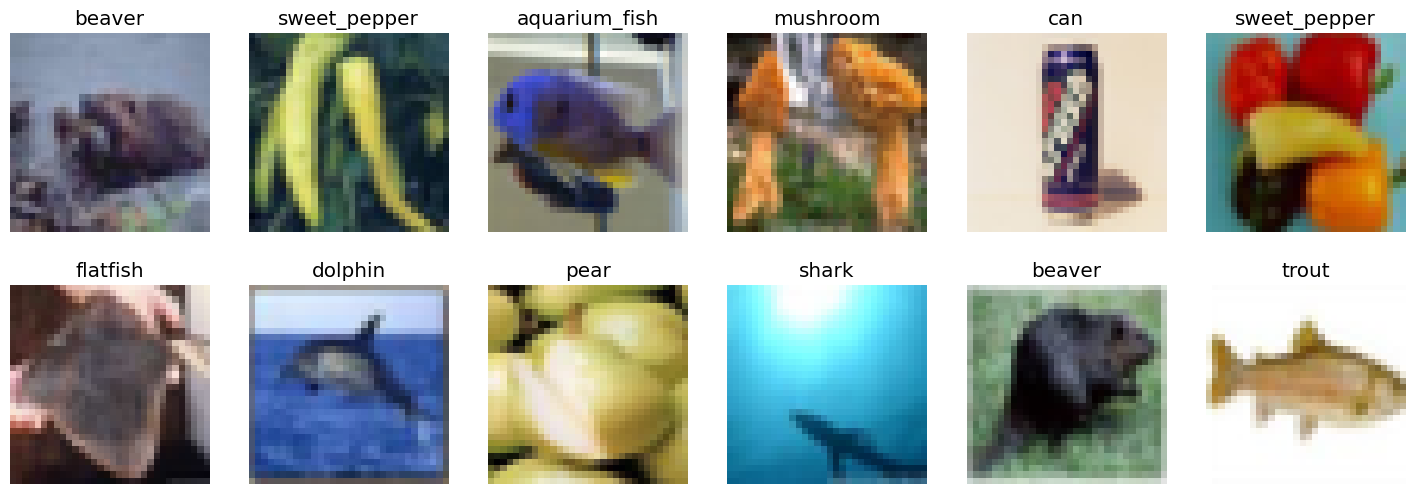

In [ ]:
print('Example of validation data')
dls.valid.show_batch(max_n=12, nrows=2)

Ahora procedemos con la creación y entrenamiento de la red BaseNet.

La red BaseNet es una red convolucional que consta de las siguientes capas:

- Una capa convolucional con 3 canales de entrada, 5 canales de salida, un tamaño de kernel de 9, sin padding.
- Una capa de activación sigmoidal.
- Una capa de pooling con un tamaño de kernel de 2.
- Una capa convolucional con 5 canales de entrada, 10 canales de salida, un tamaño de kernel de 7, sin padding.
- Una capa de activación tangente hiperbólica.
- Una capa de flattening.
- Una capa completamente conectada con 360 neuronas de entrada y 50 neuronas de salida.
- Una capa de activación relu.
- Una capa completamente conectada con 50 neuronas de entrada y 25 neuronas de salida.

Usos de las capas:

- Las capas convolucionales sirven para extraer características de las imágenes.
- Las capas de activación sigmoidal, tangente hiperbólica y relu sirven para introducir no linealidades en la red.
- La capa de pooling sirve para reducir la dimensionalidad de las imágenes.
- La capa de flattening sirve para convertir las imágenes en un vector unidimensional, necesario para las capas completamente conectadas.
- Las capas completamente conectadas sirven para hacer la clasificación de las imágenes.

Con lo que respecta a la ultima capa, no se ha añadido ninguna función de activación, ya que en fastai, la función de activación se añade automáticamente según el tipo de problema que se esté tratando. En este caso, al ser un problema de clasificación, la función de activación que se añade es la softmax.

In [ ]:
import torch.nn as nn

BaseNet = sequential(
    nn.Conv2d(3, 5, kernel_size=(9,9)),
    nn.Sigmoid(),
    nn.MaxPool2d(2,2),
    nn.Conv2d(5, 10, kernel_size=(7,7)),
    nn.Tanh(),
    nn.Flatten(),
    nn.Linear(360, 50),
    nn.ReLU(),
    nn.Linear(50, 25)
)

BaseNet

Sequential(
  (0): Conv2d(3, 5, kernel_size=(9, 9), stride=(1, 1))
  (1): Sigmoid()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(5, 10, kernel_size=(7, 7), stride=(1, 1))
  (4): Tanh()
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=360, out_features=50, bias=True)
  (7): ReLU()
  (8): Linear(in_features=50, out_features=25, bias=True)
)

Para la función de pérdida, se ha utilizado CrossEntropyLossFlat, ya que es la que se utiliza en problemas de clasificación y he usado la version flat para que fastai se encargue de hacer el flatten de las predicciones y los targets automáticamente y no tener que hacerlo manualmente.

También he añadido las metricas de accuracy y f1_score weighted, como se pide en el enunciado.

El optimizador por defecto que se utiliza en fastai es Adam, por lo que no he tenido que añadirlo manualmente.  La versión de Adam es AdamW que es una versión de Adam con corrección un bug que tenía Adam en la implementación de la regularización L2.

In [ ]:
# A CUBRIR POR EL ALUMNADO
learner : Learner = Learner(dls, BaseNet, loss_func=CrossEntropyLossFlat(), metrics=[fastai.metrics.accuracy, fastai.metrics.F1Score(average='weighted')])

Al hacer el cálculo de los parámetros, se tiene que tener en cuenta lo siguiente:

- Las capas convolucionales se calculan de la siguiente forma: $(ce \cdot k \cdot k + 1) \cdot cs$, donde $ce$ es el número de canales de entrada, $k$ es el tamaño del kernel y $cs$ es el número de canales de salida.
- Las capas completamente conectadas se calculan de la siguiente forma: $(ce \cdot cs) + cs$, donde $ce$ es el número de neuronas de entrada y $cs$ es el número de neuronas de salida.

Las capas de pooling, activación y flattening no tienen parámetros, por lo que no se tienen en cuenta en el cálculo.

In [ ]:
# Calculo de la cantidad de parametros

params = 0
#Parámetros de la primera capa convolucional
params += 5*(3*9*9 + 1) # 3 canales de entrada, 5 filtros, 9x9 tamaño del kernel
#La sigmoide no tiene parámetros
#La capa de pooling no tiene parámetros
#Parámetros de la segunda capa convolucional
params += 10*(5*7*7 + 1) # 5 canales de entrada, 10 filtros, 7x7 tamaño del kernel
#La tangente hiperbólica no tiene parámetros
#La capa de aplanamiento no tiene parámetros
#Parámetros de la primera capa densa
params += (360*50) + 50 # 360 entradas, 50 salidas
#La ReLU no tiene parámetros
#Parámetros de la segunda capa densa
params += (50*25) + 25 # 50 entradas, 25 salidas

print('Número de parámetros de la red:', params)
total_params = sum(p.numel() for p in learner.model.parameters())
print('Número total de parámetros de la red según PyTorch:', total_params)

Número de parámetros de la red: 23005
Número total de parámetros de la red según PyTorch: 23005


In [ ]:
learner.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 5 x 24 x 24   
Conv2d                                    1220       True      
Sigmoid                                                        
____________________________________________________________________________
                     128 x 5 x 12 x 12   
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 10 x 6 x 6    
Conv2d                                    2460       True      
Tanh                                                           
____________________________________________________________________________
                     128 x 360           
Flatten                                                        
____________________________________________________________________________
                     128 x 50   

Ahora vamos a entrenar el modelo con un early stopping de 5 y 25 épocas, como se pide en el enunciado.

He elegido el entrenamiento con política de un ciclo, ya que es una política de entrenamiento que se ha demostrado que es muy efectiva en la práctica. Se basa en aumentar el lr de forma lineal hasta un valor máximo y luego disminuirlo de forma lineal hasta un valor mínimo. Además, se va disminuyendo el momentum de forma lineal hasta un valor mínimo y luego se va aumentando de forma lineal hasta un valor máximo. Esto permite que el modelo pueda converger más rápido y con menos épocas.

Un lr alto permite que avancemos más rápido en la dirección correcta, pero si es demasiado alto, podemos saltarnos el mínimo y no llegar a converger. Por otro lado, un lr bajo permite que avancemos más despacio, pero si es demasiado bajo, podemos quedarnos atascados en un mínimo local y no llegar a converger, por lo que es importante encontrar un buen equilibrio.

Por otro lado el momentum es un hiperparámetro que se utiliza para acelerar el entrenamiento y que si la función de pérdida empeora, el modelo no se quede atascado en un mínimo local. Un valor alto de momentum permite que el modelo avance más rápido en la dirección correcta, pero si es demasiado alto, puede hacer que el modelo se salte el mínimo y no converja. Por otro lado, un valor bajo de momentum permite que el modelo avance más despacio, pero si es demasiado bajo, puede hacer que el modelo se quede atascado en un mínimo local y no mejore.

En este caso se va a utilizar un lr por defecto que usa fastai, más tarde usaremos el lr_finder para encontrar el mejor lr.

In [ ]:
results = learner.fit_one_cycle(25, cbs=[EarlyStoppingCallback(patience=5)])

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,3.215950,3.210410,0.068000,0.022235,00:13
1,3.106840,2.928019,0.100000,0.031489,00:13
2,2.819114,2.678052,0.139200,0.085454,00:12
3,2.669163,2.586927,0.185600,0.135947,00:12
4,2.577451,2.527672,0.211200,0.163100,00:13
5,2.511047,2.448247,0.246400,0.219653,00:13
6,2.452747,2.406655,0.250400,0.216432,00:13
7,2.400288,2.366824,0.271200,0.242454,00:13
8,2.366151,2.342927,0.269600,0.234777,00:13
9,2.341805,2.315613,0.292800,0.269543,00:13


Vemos que el modelo no mejora demasiaod en a partir de la época 10, pero el early stopping no se activa poque la función de pérdida va mejorando levemente, pero mejora.

Se observa que el modelo es muy malo, ya que la accuracy en validación es del 0.33 y el f1_score es del 0.31, un tercio de las imágenes las clasifica bien,.

⚠️ **TERRIBLE** ⚠️: El modelo necesita **más complejidad** para mejorar.

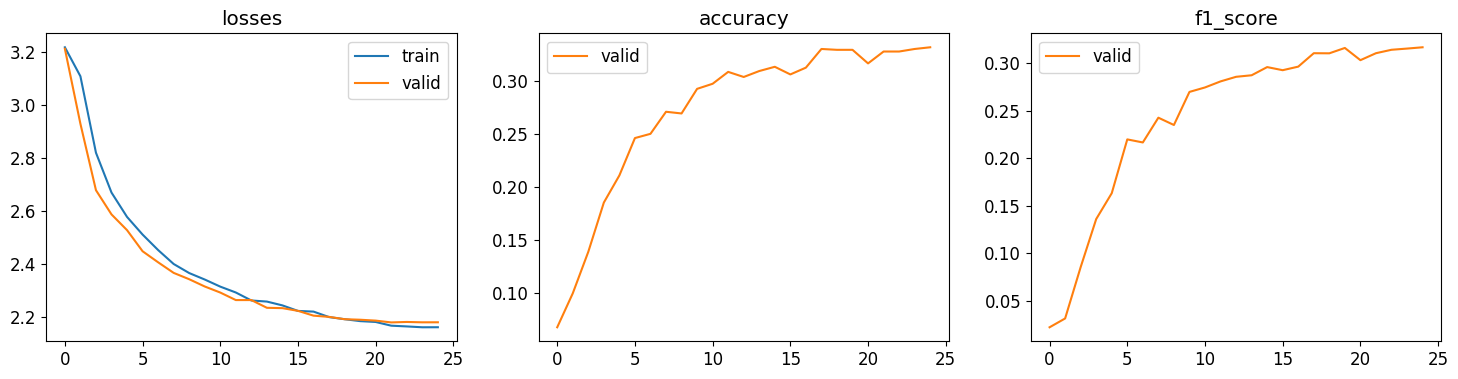

In [ ]:
learner.recorder.plot_metrics()

Lo único bueno que tiene el modelo es que no hay sobreajuste, ya que la función de pérdida en entrenamiento y validación es muy similar.

In [ ]:
# Accuracy en training y validación
preds, targs = learner.get_preds(dl=dls.train)
accuracy_train = fastai.metrics.accuracy(preds, targs)

preds, targs = learner.get_preds(dl=dls.valid)
accuracy_valid = fastai.metrics.accuracy(preds, targs)

print('Accuracy en training:', round(float(accuracy_train)*100,2), '%')
print('Accuracy en validación:', round(float(accuracy_valid)*100,2), '%')

Accuracy en training: 33.4 %
Accuracy en validación: 33.2 %


In [ ]:
test_dl = learner.dls.test_dl(get_image_files(path/'test'), with_labels=True)
preds, targs = learner.get_preds(dl=test_dl)
acc = fastai.metrics.accuracy(preds, targs)

print('Accuracy en test: ', round(float(acc)*100,2), '%')

Accuracy en test:  34.32 %


Son muy similares los aciertos en entrenamiento y validación y en test, lo que indica que no hay sobreajuste.

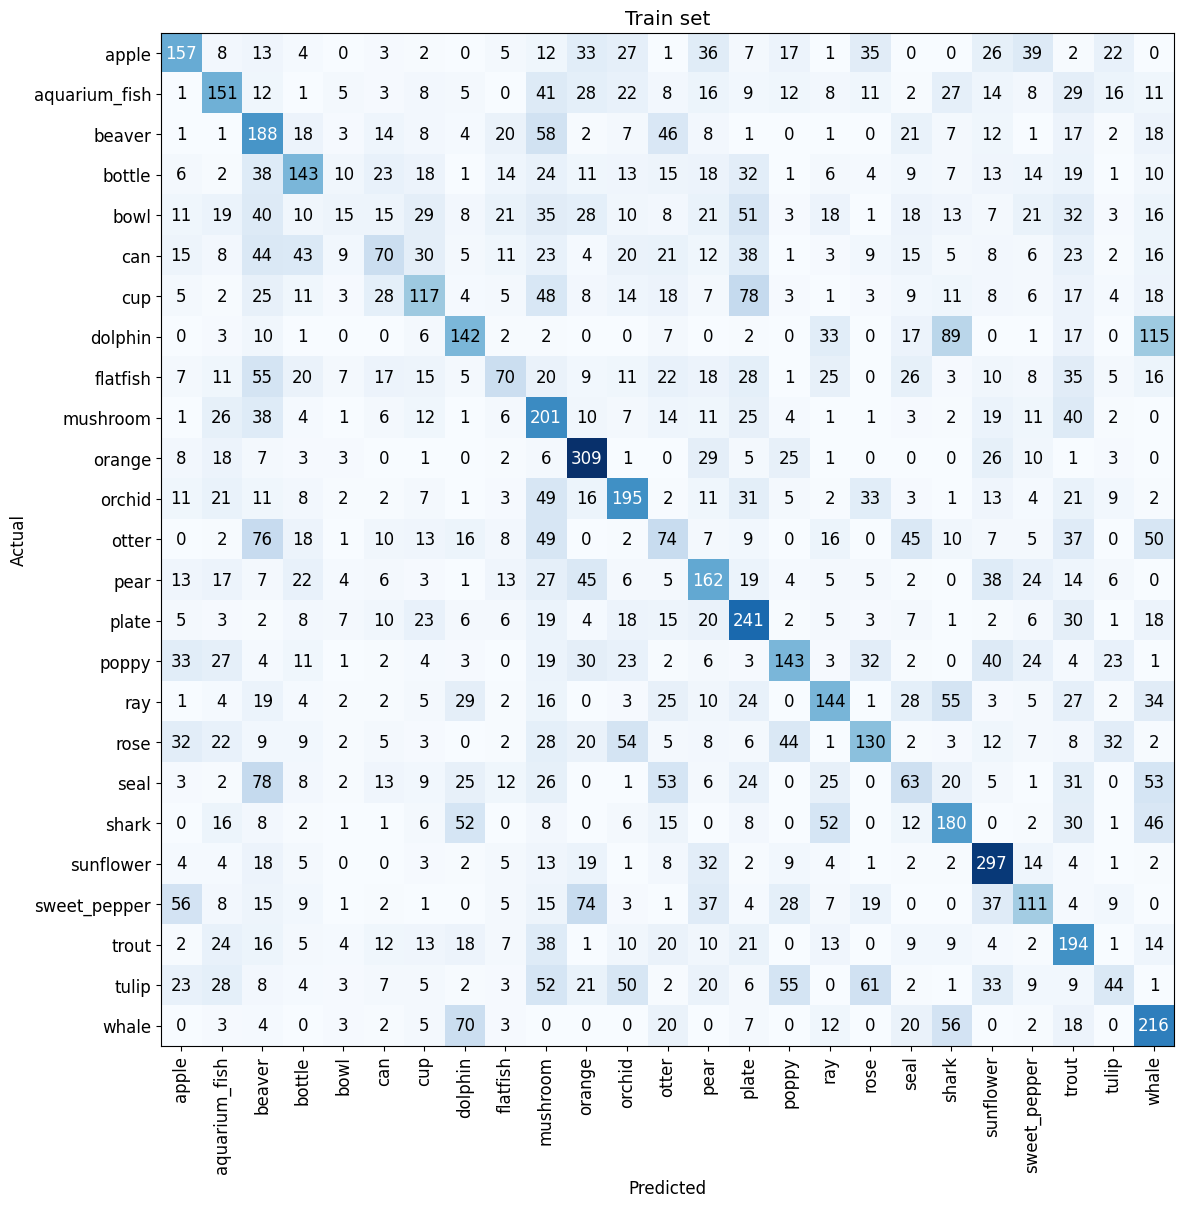

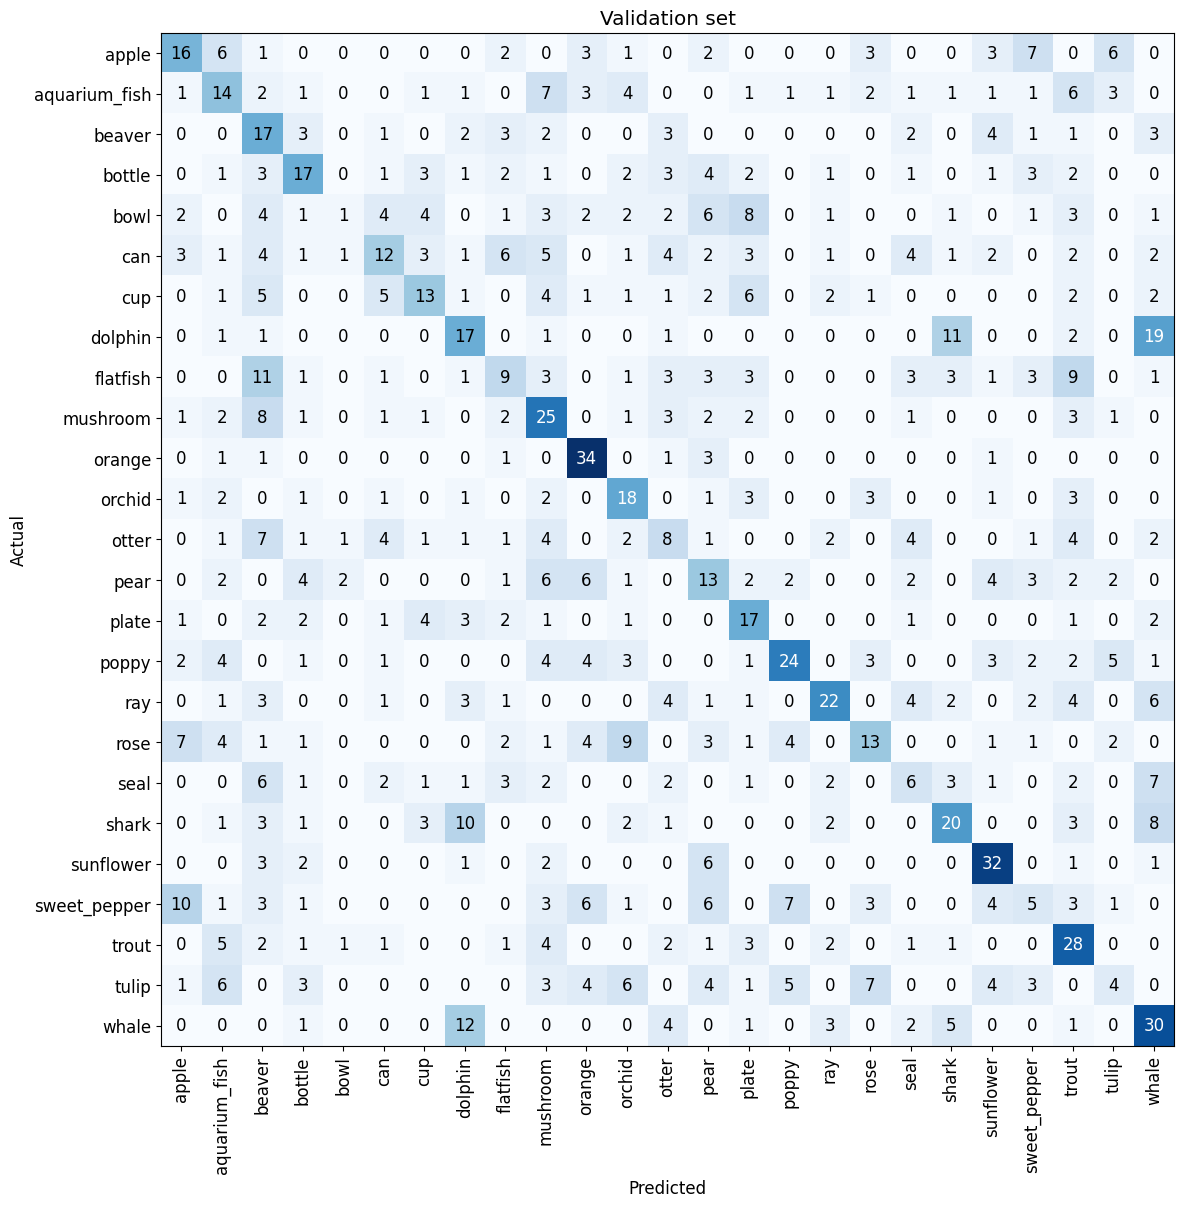

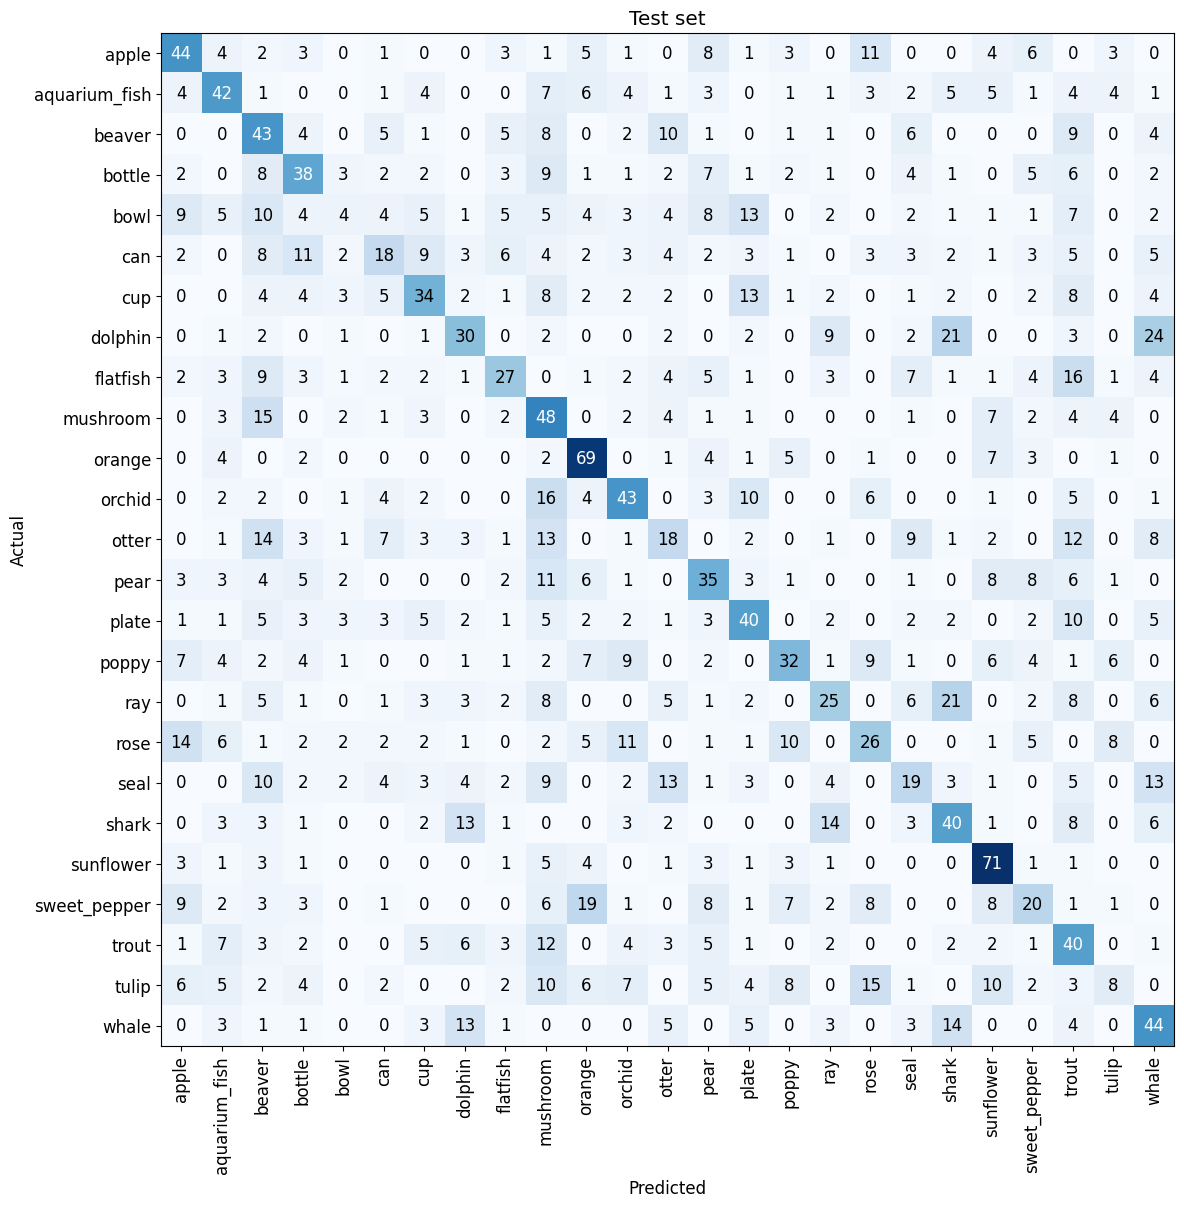

In [ ]:
#Matriz de confusión de train, valid y test
interp = ClassificationInterpretation.from_learner(learner, dl=dls.train)
interp.plot_confusion_matrix(figsize=(12,12), title='Train set')

interp = ClassificationInterpretation.from_learner(learner, dl=dls.valid)
interp.plot_confusion_matrix(figsize=(12,12), title='Validation set')

interp = ClassificationInterpretation.from_learner(learner, dl=test_dl)
interp.plot_confusion_matrix(figsize=(12,12), title='Test set')

La matriz de confusión en test es una forma de ver cómo se comporta el modelo y en cuáles clases falla más. En este caso, se ve la diagonal marcada (que son los aciertos) y hay unas clases en la que se confunde al clasificar.

Por ejemplo, confunde la clase whale con dolphin o shark. Son animales marinos, por lo que es normal que se confundan.



---



---



---



# <font color='blue'> **Ejercicio 2:** **Mejoras sobre el modelo BaseNet (4 puntos)**
<font color='blue'>Ahora el objetivo es crear una versión mejorada del modelo _Base Net_ (implementado en el anterior apartado). Para ello, se puede experimentar con distintas funciones de activación, funciones de pérdida, una mayor o menor profundidad de la red, un mayor o menor número de filtros por bloque convolucional, y/o diferentes técnicas de regularización u optimización, entre otras. De hecho, los alumnos deben sentirse libres para experimentar e incorporar todas las modificaciones que consideren pertinentes, incluyendo elementos no vistos ni en teoría ni en prácticas (por ejemplo, componentes que hayan podido descubrir a través de la revisión de artículos científicos). **Se valorará la originalidad y complejidad de la propuesta realizada.**

<font color='blue'>Es necesario destacar que **es imprescindible justificar de la mejor forma posible las decisiones tomadas** (ya sea mediante evidencia empírica o mediante literatura científica), **así como el rendimiento obtenido** (esto es, intentar explicar qué es lo que hace que mejore tanto el rendimiento). También es importante remarcar que **las mejoras introducidas, dentro de lo posible, deben realizarse de forma incremental**, es decir, no basta con crear directamente (de forma mágica) un único modelo y evaluarlo:  **es necesario justificar y describir qué pasos y resultados intermedios nos han llevado a diseñar ese modelo concreto**. Se debe describir cada una de las mejoras incorporadas, así como analizar los resultados obtenidos (del mismo modo que se hizo en el Ejercicio 1, y empleando los mismos criterios de partida; por ejemplo, usando un $10\%$ de los ejemplos de entrenamiento para validación). También es necesario, al igual que en el Ejercicio 1, desglosar el número de parámetros del modelo final, y se debe hacer un `summary()` del modelo para verificar que la arquitectura se ha construido correctamente y que el número de parámetros se corresponde con lo esperado.  

<font color='blue'>Como referencia para los estudiantes, se espera que la _accuracy_ en validación alcance, como mínimo, el $65\%$.


Ya que el modelo Base Net es muy simple, se puede mejorar de muchas formas. Por ejemplo, se puede añadir más capas convolucionales, más capas completamente conectadas, más filtros por bloque convolucional, más neuronas por capa completamente conectada, más dropout, más regularización, más optimización, etc.

Primero, lo que voy a probar es a cambiar el tamaño de los filtros de las capas convolucionales a 3x3, ya que por evidencia empírica se ha demostrado que los filtros más grandes son mejores para extraer características de las imágenes. Además, requieren menos parámetros. He aplicado padding para no perder dimensionalidad en las imágenes al aplicar las capas convolucionales.

Además, he usado como función de activación la ReLU, ya que es la que se utiliza en la mayoría de las redes convolucionales y es la que mejor funciona en la práctica.

In [ ]:
BaseNetv2 = sequential(
    nn.Conv2d(3, 5, kernel_size=(3,3), padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Conv2d(5, 10, kernel_size=(3,3), padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(2560, 50),
    nn.ReLU(),
    nn.Linear(50, 25)
)

Voy a usar los mismos tipos de learner para todas las pruebas, para comparar los resultados entre ellos mejor.

In [ ]:
learner2 : Learner = Learner(
    dls,
    BaseNetv2,
    loss_func=CrossEntropyLossFlat(),
    metrics=[fastai.metrics.accuracy, fastai.metrics.F1Score(average='weighted')]
)

In [ ]:
learner2.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 5 x 32 x 32   
Conv2d                                    140        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 5 x 16 x 16   
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 10 x 16 x 16  
Conv2d                                    460        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 2560          
Flatten                                                        
____________________________________________________________________________
                     128 x 50   

Los parámetros de la red ha aumentado a 129.000 parámetros, lo que indica que la red es más compleja y tiene más capacidad para aprender. La mayoría de los parámetros se encuentran en las capas completamente conectadas, ya que tienen muchas neuronas.

Pero el número de parámetros ha disminuido en las capas convolucionales, ya que los filtros son más pequeños y requieren menos parámetros.

Vamos a usar el lr_finder para encontrar el mejor lr para el modelo.

Lr_finder es una técnica que se utiliza para encontrar el mejor lr para el modelo. Se basa en aumentar el lr de forma exponencial y ver cómo cambia la función de pérdida. Se elige un lr que esté en la parte descendente de la curva de pérdida, ya que es el que permite que el modelo converja más rápido y con menos épocas.

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

Learning rate: SuggestedLRs(valley=0.0006918309954926372)


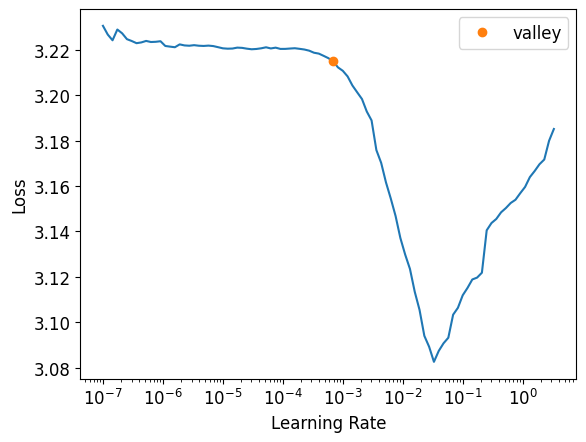

In [ ]:
#Encontar el learning rate óptimo
lr = learner2.lr_find()

print('Learning rate:', lr)

Vamos ha usar 20 épocas en vez de 25 para todas las pruebas para que tarde menos tiempo en entrenar.

En el modelo final usaremos 50 épocas para ver el potencial del modelo.

In [ ]:
learner2.fit_one_cycle(20, lr, cbs=[EarlyStoppingCallback(patience=5, min_delta=0.01)])

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,3.188221,3.140245,0.115200,0.065559,00:13
1,2.936030,2.662895,0.210400,0.177724,00:13
2,2.576564,2.418693,0.251200,0.226115,00:13
3,2.411257,2.309454,0.289600,0.268518,00:13
4,2.305889,2.249906,0.312800,0.298816,00:13
5,2.233709,2.218669,0.304800,0.292599,00:13
6,2.179307,2.159213,0.344000,0.333282,00:13
7,2.128951,2.117280,0.340800,0.334731,00:13
8,2.084347,2.097618,0.348800,0.334314,00:13
9,2.039537,2.074464,0.368800,0.360077,00:13


Han mejorado los resultados pero tenemos mucho que mejorar, se ha conseguido una mejora del 5%. El modelo necesita más complejidad para mejorar.

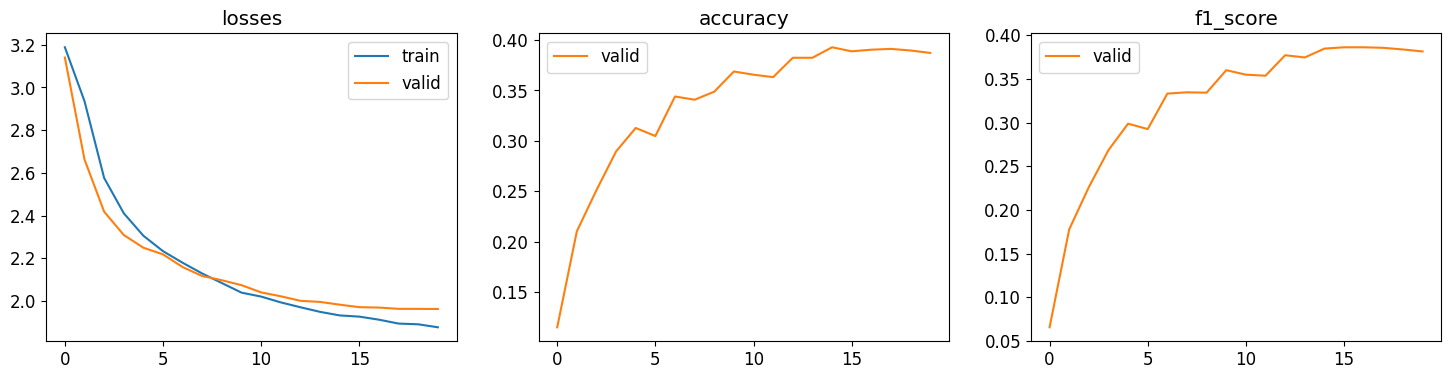

In [ ]:
learner2.recorder.plot_metrics()

El sobreajuste ha aumentado. Vamos a adoptar la entrategia de sobreajustar y luego regularizar, ya que es una estrategia que se ha demostrado que es muy efectiva en la práctica.

He añadido un bloque convolucional más, para que la red sea más profunda y pueda extraer más características de las imágenes. Además, he añadido más filtros por bloque convolucional, para que la red sea más compleja y tenga más capacidad para aprender.

Con esto vamos a sobreajustar más, pero vamos a conseguir una red más compleja y con más capacidad para aprender.

In [ ]:
BaseNetv3 = sequential(
    nn.Conv2d(3, 100, kernel_size=(3,3), padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Conv2d(100, 200, kernel_size=(3,3), padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Conv2d(200, 400, kernel_size=(3,3), padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Flatten(),

    nn.Linear(6400, 50),
    nn.ReLU(),

    nn.Linear(50, 25)
)

In [ ]:
learner3 : Learner = Learner(
    dls,
    BaseNetv3,
    loss_func=CrossEntropyLossFlat(),
    metrics=[fastai.metrics.accuracy, fastai.metrics.F1Score(average='weighted')]
)

In [ ]:
learner3.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 100 x 32 x 32 
Conv2d                                    2800       True      
ReLU                                                           
____________________________________________________________________________
                     128 x 100 x 16 x 16 
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 200 x 16 x 16 
Conv2d                                    180200     True      
ReLU                                                           
____________________________________________________________________________
                     128 x 200 x 8 x 8   
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 400 x

Ahora el modelo tiene 1.224.000 parámetros, 10 veces más que el modelo anterior.

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

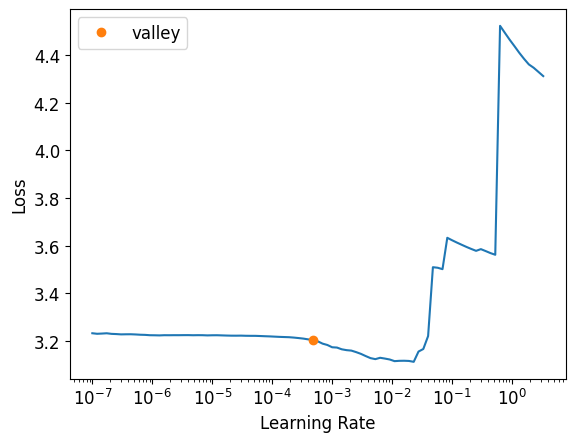

In [ ]:
lr = learner3.lr_find()

Vemos que la gráfica del lr_finder ha cambiado. Esta forma en particular se debe a que no estamos usando batchnorm, que es una técnica que normaliza los batches y que permite que el lr_finder funcione mejor.

In [ ]:
learner3.fit_one_cycle(20, lr, cbs=[EarlyStoppingCallback(patience=5, min_delta=0.01)])

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,3.098155,2.888025,0.158400,0.105029,00:13
1,2.675749,2.419557,0.269600,0.228893,00:13
2,2.392257,2.258797,0.298400,0.268024,00:13
3,2.196691,2.138846,0.327200,0.315691,00:13
4,2.020750,1.896010,0.420800,0.407951,00:13
5,1.876997,1.823178,0.440800,0.424625,00:13
6,1.760144,1.726888,0.470400,0.464870,00:13
7,1.650625,1.682500,0.486400,0.478140,00:14
8,1.569471,1.551321,0.516800,0.505628,00:14
9,1.486364,1.512488,0.507200,0.501922,00:14


Hemos obtenido una mejora del 20% en la accuracy en validación, lo que indica que algo estamos haciendo bien.

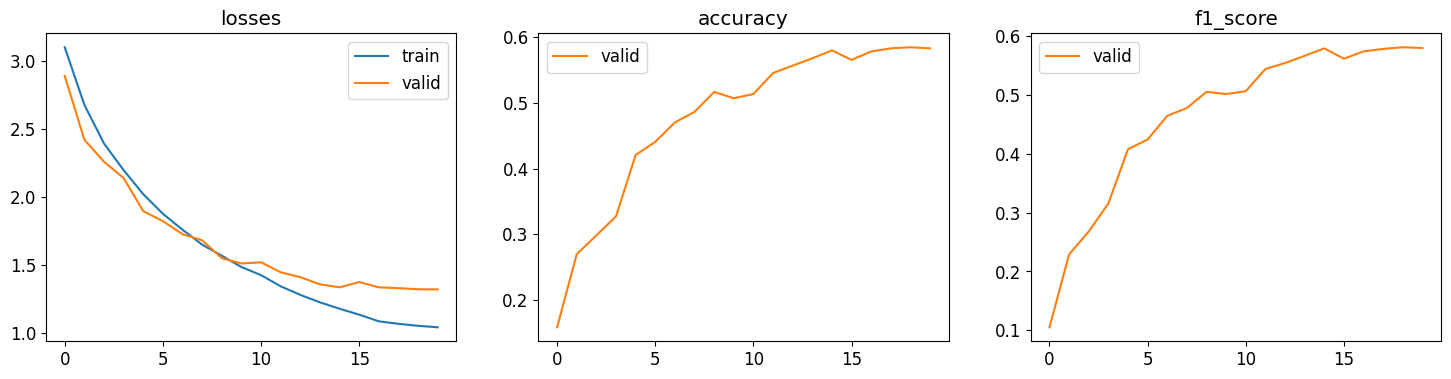

In [ ]:
learner3.recorder.plot_metrics()

El sobreajuste ha aumentado, pero no es muy grande, por lo que no es un problema, es algo que estaba previsto.

Voy a seguir añadiendo más complejidad a la red, para ver si mejora.

In [ ]:
BaseNetv4 = sequential(
    nn.Conv2d(3, 200, kernel_size=(3,3), padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Conv2d(200, 400, kernel_size=(3,3), padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Conv2d(400, 800, kernel_size=(3,3), padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Flatten(),

    nn.Linear(12800, 50),
    nn.ReLU(),

    nn.Linear(50, 25)
)

In [ ]:
learner4 : Learner = Learner(
    dls,
    BaseNetv4,
    loss_func=CrossEntropyLossFlat(),
    metrics=[fastai.metrics.accuracy, fastai.metrics.F1Score(average='weighted')]
)

In [ ]:
learner4.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 200 x 32 x 32 
Conv2d                                    5600       True      
ReLU                                                           
____________________________________________________________________________
                     128 x 200 x 16 x 16 
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 400 x 16 x 16 
Conv2d                                    720400     True      
ReLU                                                           
____________________________________________________________________________
                     128 x 400 x 8 x 8   
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 800 x

Ahora son 4,248,000 parámetros, mas o menos 4 veces más que el modelo anterior.

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

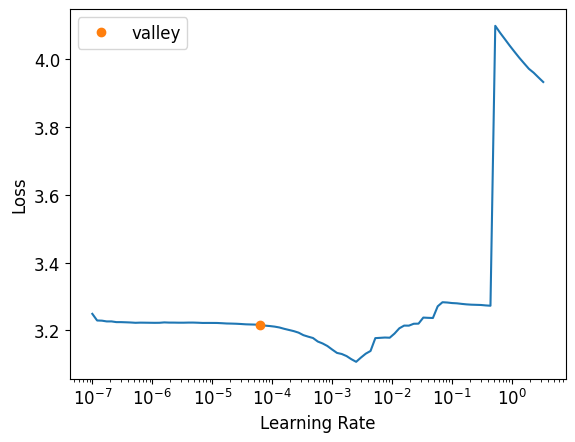

In [ ]:
lr = learner4.lr_find()

La forma de la gráfica del lr_finder es más exagerada que el anterior, podría indicar que es muy necesario el uso de batchnorm.

In [ ]:
learner4.fit_one_cycle(20, lr, cbs=[EarlyStoppingCallback(patience=5, min_delta=0.01)])

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,3.196699,3.175763,0.087200,0.035396,00:14
1,3.032389,2.859180,0.156800,0.095785,00:14
2,2.732586,2.583154,0.224000,0.173588,00:14
3,2.503572,2.398346,0.260000,0.249173,00:14
4,2.331894,2.252810,0.324000,0.304511,00:14
5,2.207943,2.154911,0.356000,0.339190,00:14
6,2.106998,2.072087,0.372800,0.357031,00:14
7,2.034230,2.026443,0.366400,0.370670,00:14
8,1.965780,1.962257,0.407200,0.397451,00:14
9,1.907289,1.901434,0.422400,0.408474,00:14


Vemos que el modelo ha emperorado, por lo que vamos a tener que regularizarlo.

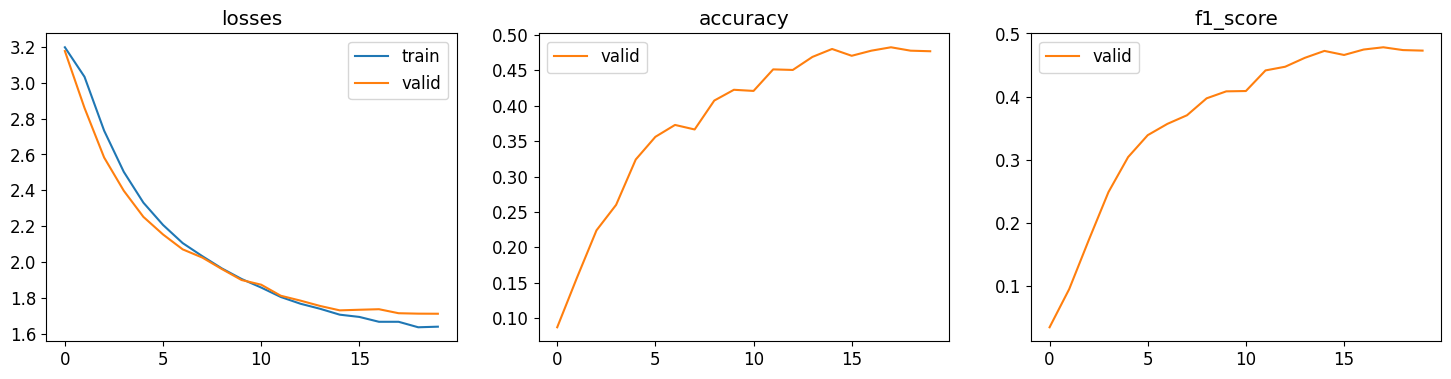

In [ ]:
learner4.recorder.plot_metrics()

Vamos a probar primero añadiendo batchnorm a la red. Bathnorm es una técnica que normaliza los batches. Previene el sobreajuste, ya que hace que el modelo sea más robusto a los cambios en los datos.

Batchnorm se añade después de las capas convolucionales y antes de las capas de activación. También después de cada capa completamente conectada. Es la forma que ha demostrado ser más efectiva empíricamente.

Usa dos parámetros, gamma y beta, que se aprenden durante el entrenamiento, por lo que tenemos 2 parámetros más por filtro de salida de las capas convolucionales y por neuronas de salida de las capas completamente conectadas.

In [ ]:
BaseNetv5 = sequential(
    nn.Conv2d(3, 200, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(200),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Conv2d(200, 400, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(400),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Conv2d(400, 800, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(800),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Flatten(),

    nn.Linear(12800, 50),
    nn.BatchNorm1d(50),
    nn.ReLU(),

    nn.Linear(50, 25)
)

In [ ]:
learner5 : Learner = Learner(
    dls,
    BaseNetv5,
    loss_func=CrossEntropyLossFlat(),
    metrics=[fastai.metrics.accuracy, fastai.metrics.F1Score(average='weighted')]
)

In [ ]:
learner5.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 200 x 32 x 32 
Conv2d                                    5600       True      
BatchNorm2d                               400        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 200 x 16 x 16 
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 400 x 16 x 16 
Conv2d                                    720400     True      
BatchNorm2d                               800        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 400 x 8 x 8   
MaxPool2d                                    

Hay 4,251,000 parámetros, un poco más que el modelo anterior.

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

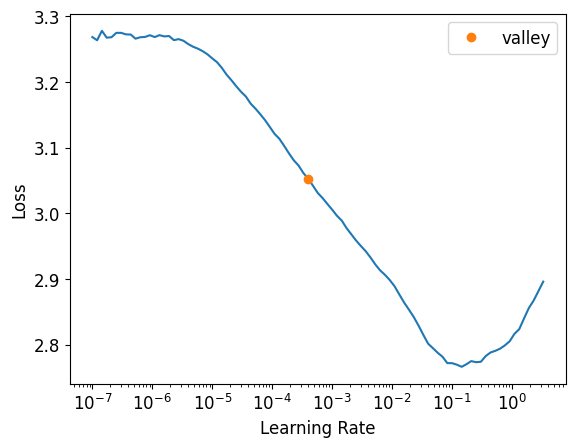

In [ ]:
lr = learner5.lr_find()

El lr_finder ha mejorado, ya tiene una forma más normal, lo que indica que batchnorm ha mejorado el rendimiento del modelo y que el lr_finder funciona mejor.

In [ ]:
learner5.fit_one_cycle(20, lr_max=lr, cbs=[EarlyStoppingCallback(patience=5, min_delta=0.01)])

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.754759,2.621500,0.293600,0.259741,00:13
1,2.569008,2.471162,0.356800,0.326767,00:13
2,2.383219,2.257746,0.423200,0.407919,00:14
3,2.184309,2.056845,0.479200,0.460656,00:14
4,1.959889,1.862690,0.489600,0.486905,00:14
5,1.771387,1.670842,0.525600,0.516519,00:14
6,1.621990,1.557797,0.557600,0.546374,00:15
7,1.473866,1.467387,0.548000,0.545528,00:15
8,1.373697,1.447950,0.564000,0.565621,00:15
9,1.273413,1.348408,0.590400,0.579828,00:15


Vemos que el rendimiento ha aumentado en un 20% con respecto al modelo anterior, y con respecto al anterior del anterior, un 9%. Además, alcanzamos el objetivo del 65% de accuracy en validación.

Por tanto, batchnorm ha mejorado el rendimiento del modelo.

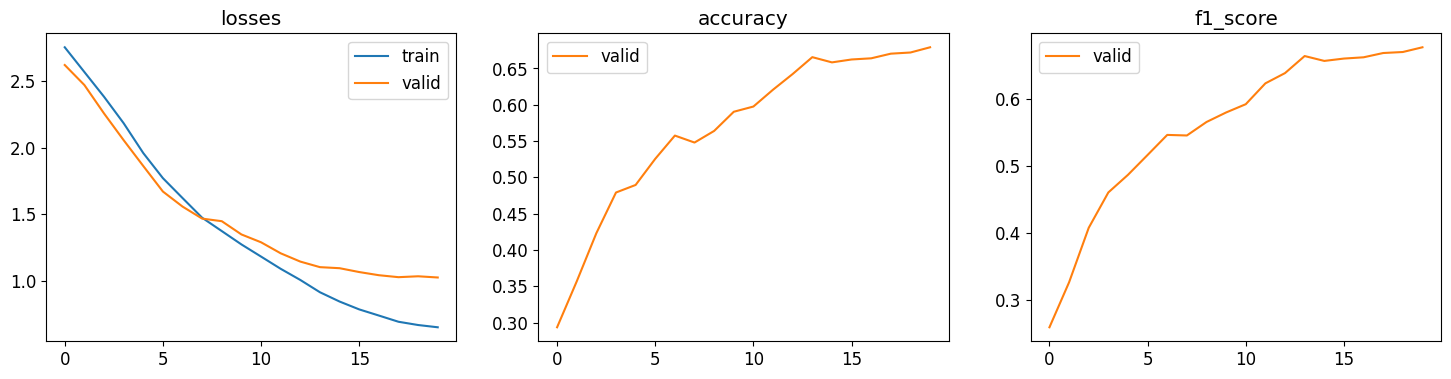

In [ ]:
learner5.recorder.plot_metrics()

El sobreajuste ha aumentado extrañamente, pero no es un problema.

Vamos a intentar regularizar el modelo con dropout. Vamos a probar un dropout del 0.3. Estos valores de dropout son los que se han demostrado que son más efectivos según la red que se esté utilizando:

- Para redes convolucionales relativamente pequeñas, se suele utilizar un dropout del 0.2.
- Para redes convolucionales más grandes, se suele utilizar un dropout del 0.3.
- Para redes convolucionales muy profundas, se suele utilizar un dropout del 0.4 o 0.5.

Vamos a probar con 0.3 que es un valor intermedio.

Dropout consiste en apagar de forma aleatoria un porcentaje de las neuronas de la red durante el entrenamiento. Esto previene el sobreajuste, ya que hace que el modelo sea más robusto a los cambios en los datos. Después en validación, se activan todas las neuronas, y los valores que se han apagado se multiplican por el porcentaje de dropout, para no sobreexcitar las neuronas.

In [ ]:
BaseNetv6 = sequential(
    nn.Conv2d(3, 200, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(200),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),

    nn.Conv2d(200, 400, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(400),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),

    nn.Conv2d(400, 800, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(800),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),

    nn.Flatten(),

    nn.Linear(12800, 50),
    nn.BatchNorm1d(50),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(50, 25)
)

In [ ]:
learner6 : Learner = Learner(
    dls,
    BaseNetv6,
    loss_func=CrossEntropyLossFlat(),
    metrics=[fastai.metrics.accuracy, fastai.metrics.F1Score(average='weighted')]
)

In [ ]:
learner6.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 200 x 32 x 32 
Conv2d                                    5600       True      
BatchNorm2d                               400        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 200 x 16 x 16 
MaxPool2d                                                      
Dropout                                                        
____________________________________________________________________________
                     128 x 400 x 16 x 16 
Conv2d                                    720400     True      
BatchNorm2d                               800        True      
ReLU                                                           
____________________________________________________________________________
                     12

Tenemos 4,251,000 parámetros, el mismo número que el modelo anterior. Dropout no añade parámetros, ya que es una técnica de regularización que se aplica durante el entrenamiento y no durante la inferencia.

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

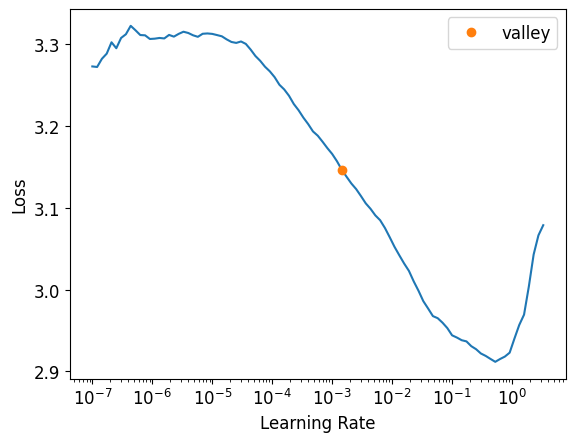

In [ ]:
lr = learner6.lr_find()

In [ ]:
learner6.fit_one_cycle(20, lr_max=lr, cbs=[EarlyStoppingCallback(patience=5, min_delta=0.01)])

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.879313,2.833239,0.200000,0.162556,00:14
1,2.674357,2.517662,0.340000,0.323526,00:14
2,2.407914,2.090588,0.405600,0.386214,00:14
3,2.141366,1.877161,0.448000,0.433598,00:14
4,1.957188,1.649561,0.491200,0.475727,00:14
5,1.832050,1.561156,0.522400,0.517133,00:15
6,1.732122,1.526582,0.532000,0.526871,00:15
7,1.659146,1.423664,0.546400,0.537927,00:15
8,1.608331,1.382743,0.560000,0.556906,00:15
9,1.518101,1.314092,0.582400,0.574020,00:15


Ha empereado el rendimiento del modelo, por lo que vamos a probar con un dropout del 0.2.

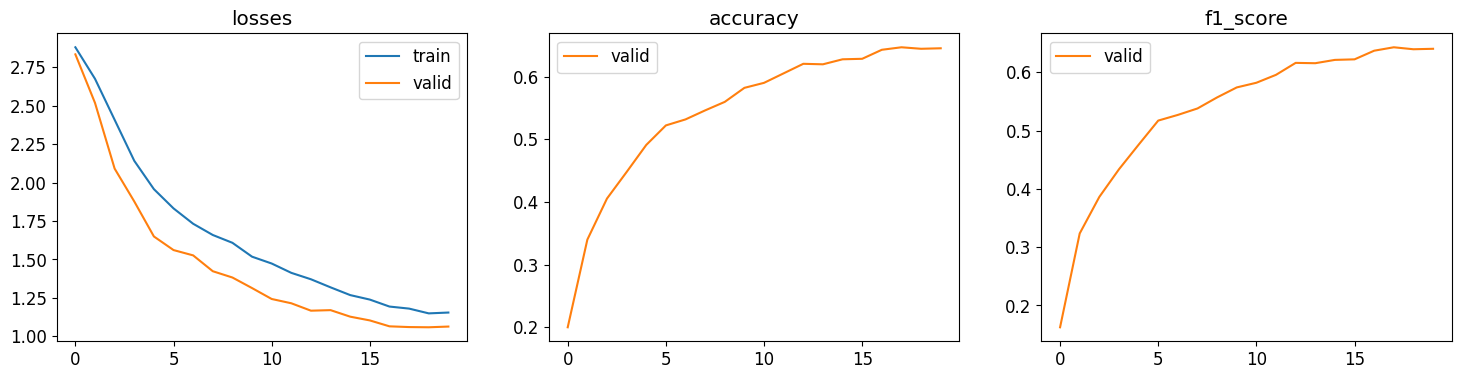

In [ ]:
learner6.recorder.plot_metrics()

También vemos que el sobreajuste ha desaparecido, y se ha invertido, el modelo está infrarajustando, por lo que vamos a probar con un dropout del 0.2. En las capas completamente conectadas, voy a utilizar un dropout del 0.1, porque tenemos menos neuronas y no queremos apagar muchas.

In [ ]:
BaseNetv7 = sequential(
    nn.Conv2d(3, 200, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(200),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.2),

    nn.Conv2d(200, 400, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(400),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.2),

    nn.Conv2d(400, 800, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(800),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.2),

    nn.Flatten(),

    nn.Linear(12800, 50),
    nn.BatchNorm1d(50),
    nn.ReLU(),
    nn.Dropout(0.1),

    nn.Linear(50, 25)
)

In [ ]:
learner7 : Learner = Learner(
    dls,
    BaseNetv7,
    loss_func=CrossEntropyLossFlat(),
    metrics=[fastai.metrics.accuracy, fastai.metrics.F1Score(average='weighted')]
)

In [ ]:
learner7.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 200 x 32 x 32 
Conv2d                                    5600       True      
BatchNorm2d                               400        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 200 x 16 x 16 
MaxPool2d                                                      
Dropout                                                        
____________________________________________________________________________
                     128 x 400 x 16 x 16 
Conv2d                                    720400     True      
BatchNorm2d                               800        True      
ReLU                                                           
____________________________________________________________________________
                     12

Mismo número de parámetros que el modelo anterior.

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

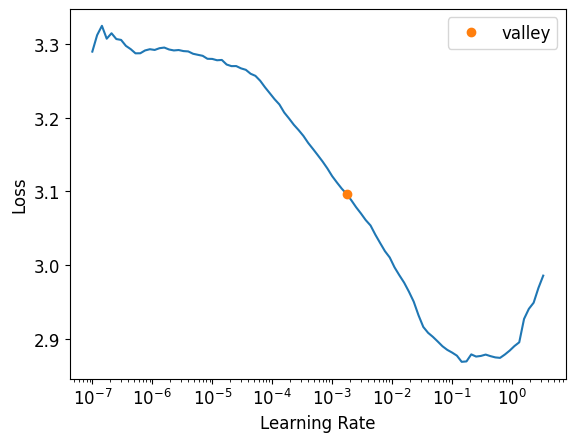

In [ ]:
lr = learner7.lr_find()

In [ ]:
learner7.fit_one_cycle(20, lr_max=lr, cbs=[EarlyStoppingCallback(patience=5, min_delta=0.01)])

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.814691,2.746223,0.236000,0.193208,00:14
1,2.547482,2.369194,0.344800,0.321956,00:14
2,2.197062,1.928323,0.421600,0.393334,00:14
3,1.910677,1.757521,0.456000,0.445010,00:14
4,1.709946,1.560197,0.500800,0.483868,00:15
5,1.586455,1.464706,0.517600,0.510137,00:15
6,1.492850,1.413633,0.532800,0.532274,00:15
7,1.395964,1.301899,0.576000,0.573882,00:15
8,1.320570,1.297150,0.582400,0.574386,00:15
9,1.258712,1.320459,0.568800,0.567644,00:15


Esta vez ha mejorado el rendimiento del modelo, por lo que estaba en lo cierto al bajar el dropout.

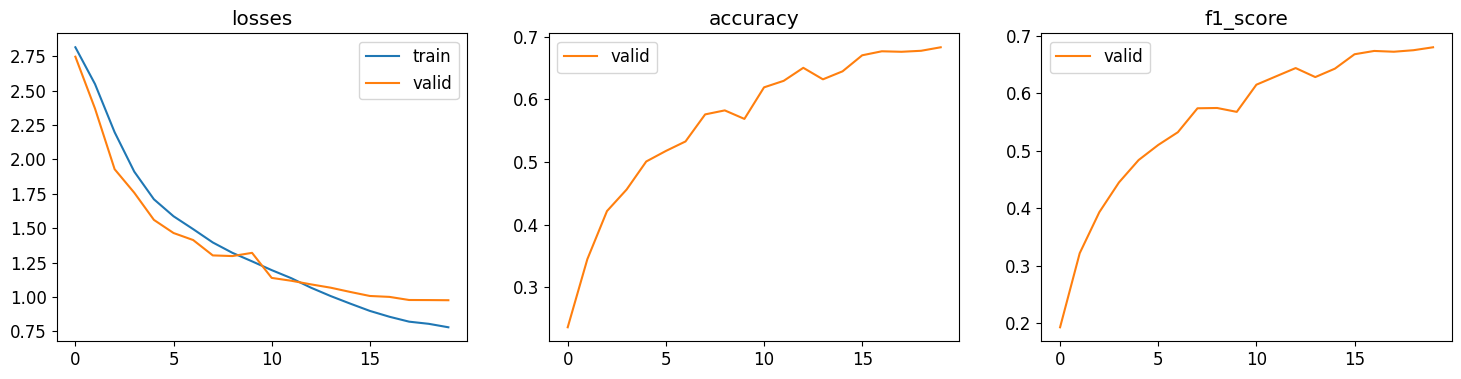

In [ ]:
learner7.recorder.plot_metrics()

Vuelve a ver algo de sobreajuste, pero no es algo exagerado, por lo que no es un problema.

Voy a probar usar convoluciones 1x1, que se ha demostrado que son muy efectivas en la práctica. Se utilizan para reducir la dimensionalidad de los filtros.

In [ ]:
BaseNetv8 = sequential(
    nn.Conv2d(3, 200, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(200),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.2),

    nn.Conv2d(200, 400, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(400),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.2),

    nn.Conv2d(400, 800, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(800),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.2),

    nn.Conv2d(800, 200, kernel_size=(1,1)),
    nn.BatchNorm2d(200),
    nn.ReLU(),

    nn.Flatten(),

    nn.Linear(3200, 50),
    nn.BatchNorm1d(50),
    nn.ReLU(),
    nn.Dropout(0.1),

    nn.Linear(50, 25)
)

In [ ]:
learner8 : Learner = Learner(
    dls,
    BaseNetv8,
    loss_func=CrossEntropyLossFlat(),
    metrics=[fastai.metrics.accuracy, fastai.metrics.F1Score(average='weighted')]
)

In [ ]:
learner8.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 200 x 32 x 32 
Conv2d                                    5600       True      
BatchNorm2d                               400        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 200 x 16 x 16 
MaxPool2d                                                      
Dropout                                                        
____________________________________________________________________________
                     128 x 400 x 16 x 16 
Conv2d                                    720400     True      
BatchNorm2d                               800        True      
ReLU                                                           
____________________________________________________________________________
                     12

El número de parámetros ha disminuido a 3,931,000, por lo hemos simplificado la red al usar convoluciones 1x1.

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

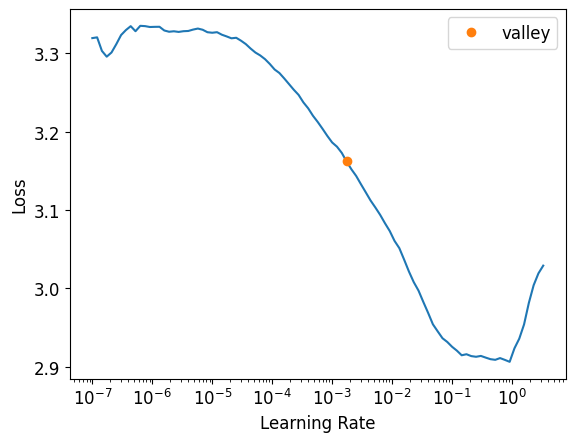

In [ ]:
lr = learner8.lr_find()

In [ ]:
learner8.fit_one_cycle(20, lr_max=lr, cbs=[EarlyStoppingCallback(patience=5, min_delta=0.01)])

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.849598,2.742014,0.260000,0.220569,00:14
1,2.560476,2.377601,0.341600,0.321495,00:14
2,2.236166,1.909960,0.432000,0.415456,00:15
3,1.934773,1.722773,0.472800,0.462852,00:15
4,1.731493,1.630405,0.469600,0.461787,00:15
5,1.593002,1.501129,0.509600,0.503727,00:15
6,1.485228,1.418778,0.527200,0.520666,00:15
7,1.402848,1.310085,0.561600,0.560871,00:15
8,1.327690,1.327871,0.562400,0.561621,00:15
9,1.276568,1.304613,0.576000,0.565937,00:16


No ha cambiado mucho el rendimiento del modelo, por lo que no es una mejora muy efectiva.

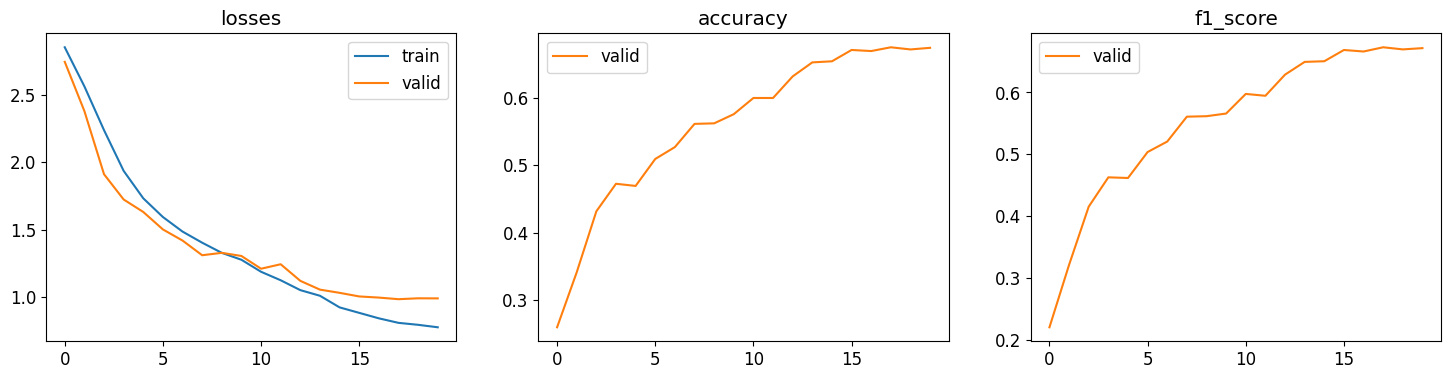

In [ ]:
learner8.recorder.plot_metrics()

El sobreajuste ha disminuido un poco, pero no es algo muy significativo.

Finalmente voy a ir con ***TODO*** en el modelo final. Voy a añadir más capas convolucionales y voy a aumentar el dropout a 0.3 en las porque el mmodelo es más profundo y complejo.

In [ ]:
DefinitiveNet = sequential(
    nn.Conv2d(3, 200, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(200),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),

    nn.Conv2d(200, 400, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(400),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),

    nn.Conv2d(400, 800, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(800),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),

    nn.Conv2d(800, 1600, kernel_size=(3,3), padding=1),
    nn.BatchNorm2d(1600),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),

    nn.Flatten(),

    nn.Linear(6400, 50),
    nn.BatchNorm1d(50),
    nn.ReLU(),
    nn.Dropout(0.1),

    nn.Linear(50, 25)
)

Aquí desgloso el número de parámetros de la red final.

In [ ]:
n_parametros = 0

#Parámetros de la primera capa convolucional
n_parametros += 200*(3*3*3 + 1) # 3 canales de entrada, 200 filtros, 3x3 tamaño del kernel
#La capa de normalización
n_parametros += 200*2 # 200 parámetros de media y 200 parámetros de varianza, es decir, 2 por filtro
#La ReLU no tiene parámetros
#La capa de pooling no tiene parámetros
#La capa de dropout no tiene parámetros

#Parámetros de la segunda capa convolucional
n_parametros += 400*(200*3*3 + 1) # 200 canales de entrada, 400 filtros, 3x3 tamaño del kernel
#La capa de normalización
n_parametros += 400*2 # 400 parámetros de media y 400 parámetros de varianza, es decir, 2 por filtro
#La ReLU no tiene parámetros
#La capa de pooling no tiene parámetros
#La capa de dropout no tiene parámetros

#Parámetros de la tercera capa convolucional
n_parametros += 800*(400*3*3 + 1) # 400 canales de entrada, 800 filtros, 3x3 tamaño del kernel
#La capa de normalización
n_parametros += 800*2 # 800 parámetros de media y 800 parámetros de varianza, es decir, 2 por filtro
#La ReLU no tiene parámetros
#La capa de pooling no tiene parámetros
#La capa de dropout no tiene parámetros

#Parámetros de la cuarta capa convolucional
n_parametros += 1600*(800*3*3 + 1) # 800 canales de entrada, 1600 filtros, 3x3 tamaño del kernel
#La capa de normalización
n_parametros += 1600*2 # 1600 parámetros de media y 1600 parámetros de varianza, es decir, 2 por filtro
#La ReLU no tiene parámetros
#La capa de pooling no tiene parámetros
#La capa de dropout no tiene parámetros

#El flatten no tiene parámetros

#Parámetros de la primera capa densa
n_parametros += 50*(6400 + 1) # 6400 entradas, 50 salidas
#La capa de normalización
n_parametros += 50*2 # 50 parámetros de media y 50 parámetros de varianza
#La ReLU no tiene parámetros
#La capa de dropout no tiene parámetros

#Parámetros de la segunda capa densa (salida)
n_parametros += 25*(50 + 1) # 50 entradas, 25 salidas

print('Número de parámetros de la red:', format(n_parametros, ',d'))
print('Número total de parámetros de la red según PyTorch:', format(sum(p.numel() for p in DefinitiveNet.parameters()), ',d'))

Número de parámetros de la red: 15,455,825
Número total de parámetros de la red según PyTorch: 15,455,825


In [ ]:
learner9 : Learner = Learner(
    dls,
    DefinitiveNet,
    loss_func=CrossEntropyLossFlat(),
    metrics=[fastai.metrics.accuracy, fastai.metrics.F1Score(average='weighted')]
)

In [ ]:
learner9.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 200 x 32 x 32 
Conv2d                                    5600       True      
BatchNorm2d                               400        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 200 x 16 x 16 
MaxPool2d                                                      
Dropout                                                        
____________________________________________________________________________
                     128 x 400 x 16 x 16 
Conv2d                                    720400     True      
BatchNorm2d                               800        True      
ReLU                                                           
____________________________________________________________________________
                     12

Son **15,455,000 PARÁMEROS**, **617 VECES MÁS** que el modelo BaseNet.

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

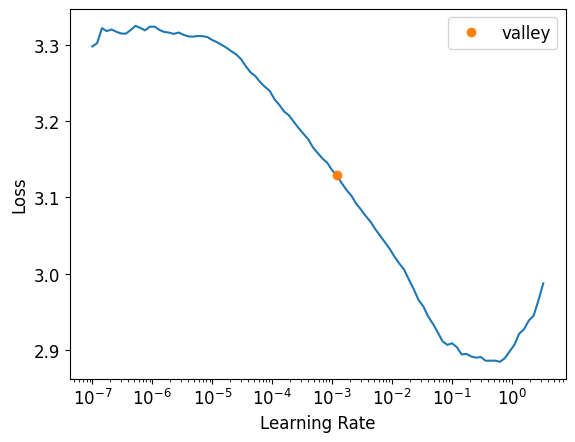

In [ ]:
lr = learner9.lr_find()

Vamos a ir con ***TODO*** en el modelo final. Así que entrenamos con 50 épocas, sin early stopping.

In [ ]:
learner9.fit_one_cycle(50, lr_max=lr)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.891110,2.979726,0.167200,0.144378,00:15
1,2.753470,2.841079,0.214400,0.194607,00:15
2,2.620249,2.608808,0.281600,0.263963,00:15
3,2.452886,2.319227,0.360000,0.341014,00:16
4,2.256677,2.087046,0.392000,0.379192,00:16
5,2.062544,1.883433,0.457600,0.436546,00:16
6,1.874004,1.897442,0.416800,0.390070,00:17
7,1.736586,1.634910,0.493600,0.481363,00:17
8,1.616506,1.563916,0.498400,0.486255,00:18
9,1.527560,1.435995,0.547200,0.549838,00:17


Vemos que el modelo ha aumentado en un 5% la accuracy en validación, pero no merece la pena el aumento de complejidad para tan poca mejora. Pero hemos alcanzado el objetivo del 65% de accuracy en validación.

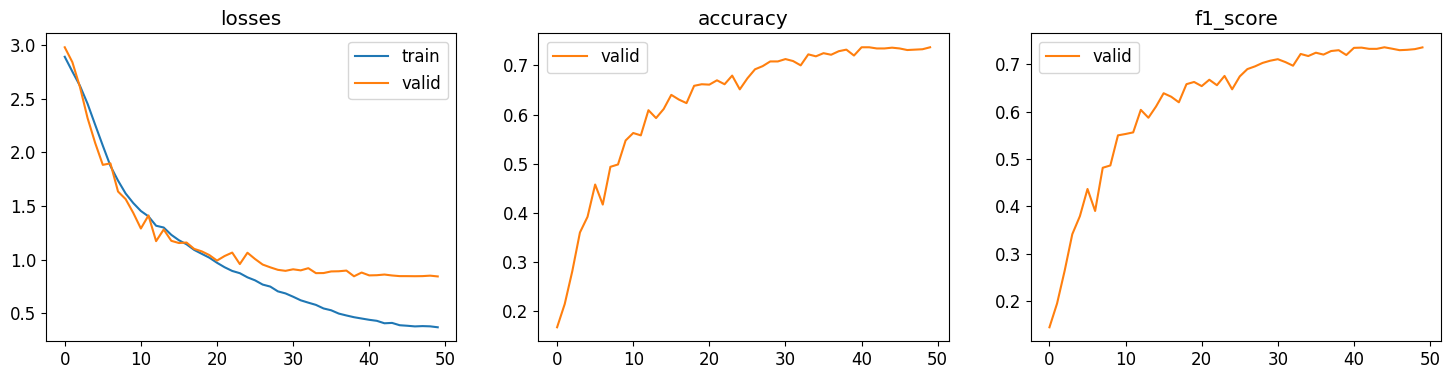

In [ ]:
learner9.recorder.plot_metrics()

El modelo sobreajusta bastante, por lo que habría que poner más dropout o regularización.

In [ ]:
# Accuracy en training y validación
preds, targs = learner9.get_preds(dl=dls.train)
accuracy_train = fastai.metrics.accuracy(preds, targs)

preds, targs = learner9.get_preds(dl=dls.valid)
accuracy_valid = fastai.metrics.accuracy(preds, targs)

print('Accuracy en training:', round(float(accuracy_train)*100,2), '%')
print('Accuracy en validación:', round(float(accuracy_valid)*100,2), '%')

Accuracy en training: 94.28 %
Accuracy en validación: 73.68 %


Las diferencias en el acierto en entrenamiento y validación son muy grandes, lo que indica que hay sobreajuste.

In [ ]:
test_dl = learner9.dls.test_dl(get_image_files(path/'test'), with_labels=True)
preds, targs = learner9.get_preds(dl=test_dl)
acc = fastai.metrics.accuracy(preds, targs)

print('Accuracy en test: ', round(float(acc)*100,2), '%')

Accuracy en test:  72.8 %


Los resultados en test son muy similares a los de validación, lo que indica que se está generalizando bien.

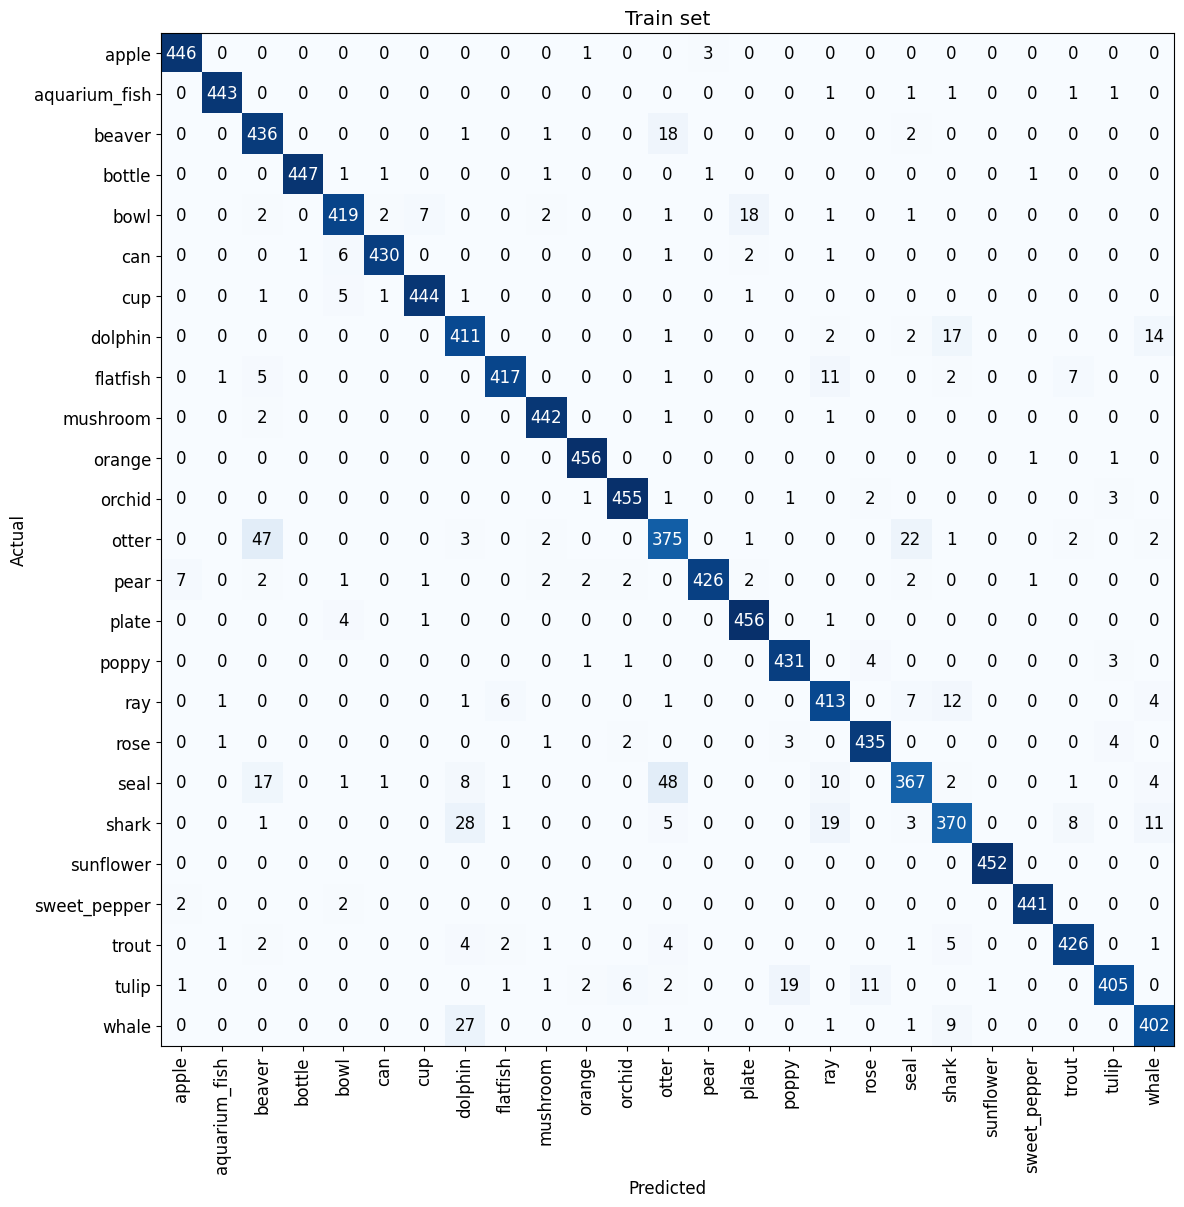

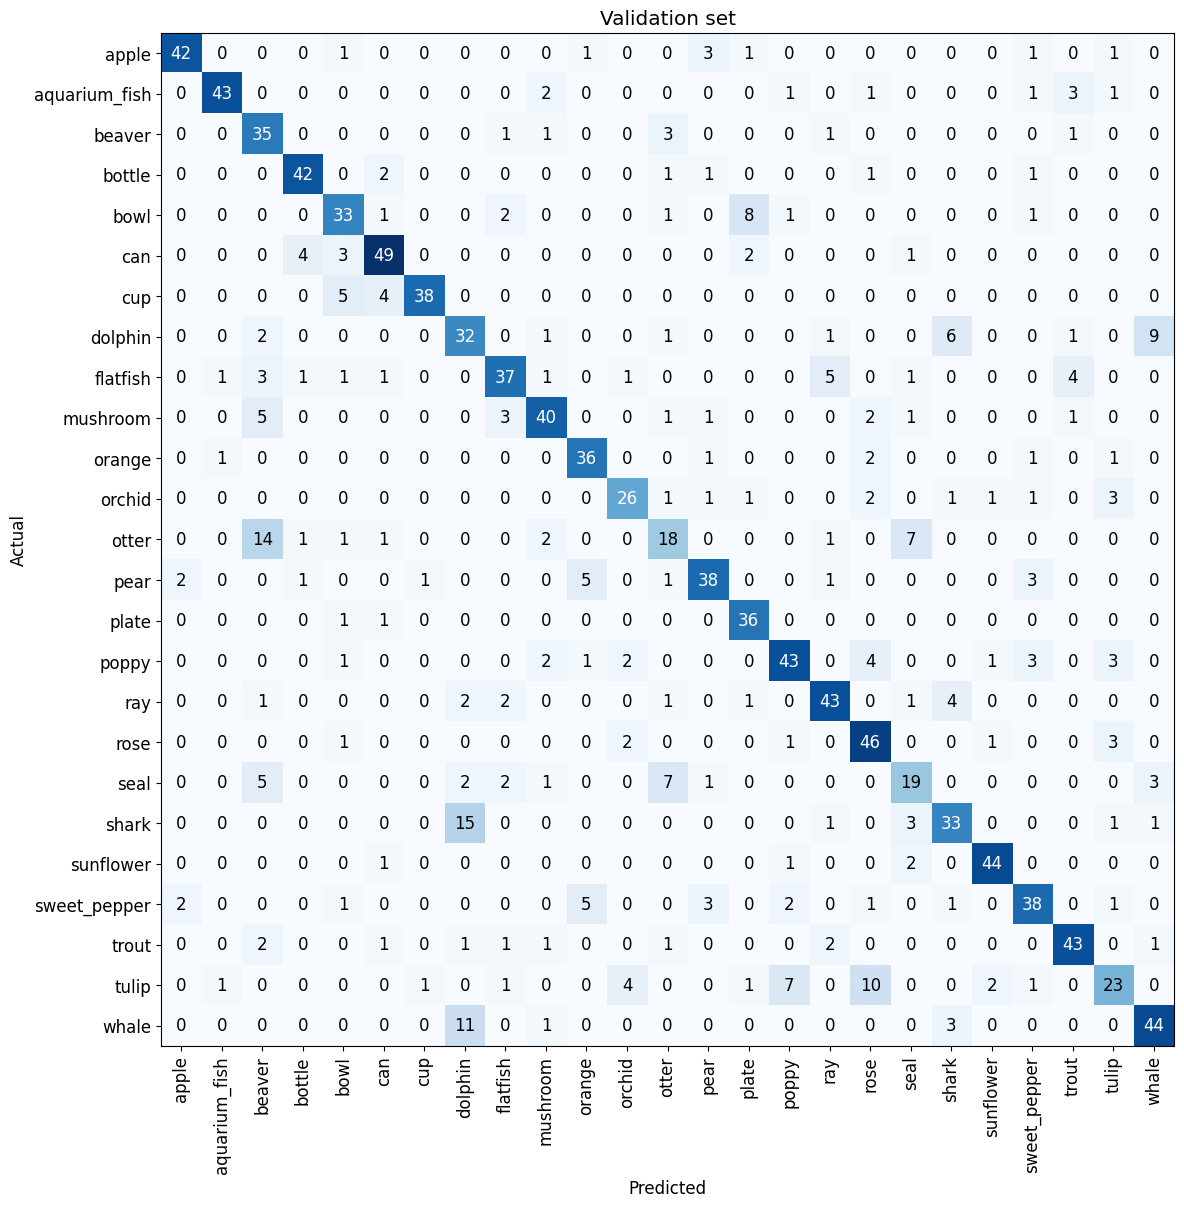

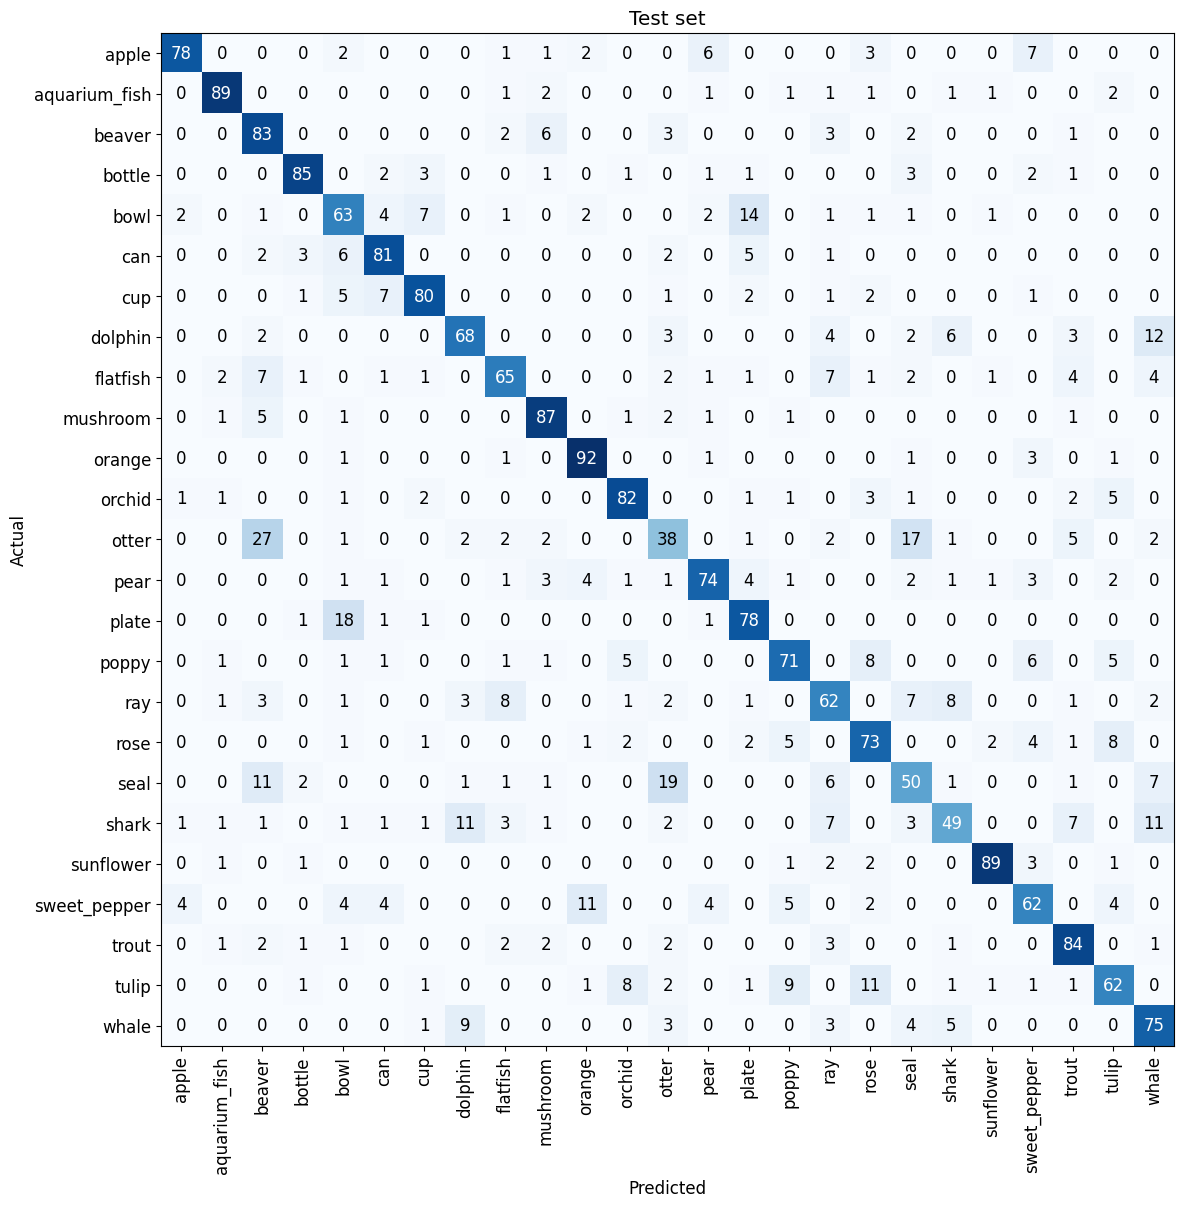

In [ ]:
#Matriz de confusión de train, valid y test
interp = ClassificationInterpretation.from_learner(learner9, dl=dls.train)
interp.plot_confusion_matrix(figsize=(12,12), title='Train set')

interp = ClassificationInterpretation.from_learner(learner9, dl=dls.valid)
interp.plot_confusion_matrix(figsize=(12,12), title='Validation set')

interp = ClassificationInterpretation.from_learner(learner9, dl=test_dl)
interp.plot_confusion_matrix(figsize=(12,12), title='Test set')

Los resultados en la matriz de confusión son bastante buenos, ya que la diagonal está muy marcada, lo que indica que el modelo está clasificando bien las imágenes. Pero sigue habiendo algunas clases en las que se confunde como en el modelo BaseNet, como las clases whale y dolphin antes mencionadas.

---



---



---